In [8]:
pwd

'/global/u2/b/bharat/repos/hwconus'

In [27]:
# Calculating heatwaves 
import matplotlib.pyplot as plt
#import intake_esgf
import matplotlib as mpl
import pandas as pd
import xarray as xr
import numpy as np
import os

import datetime as dt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import statsmodels.formula.api as smf
from scipy import ndimage, stats

import pickle
import cftime

from functions import geo_idx  # user-provided helper module (unchanged)
# Set the matplotlib default font size
mpl.rcParams['font.size'] = 16

## Notes: CESM2 all hist not available at daily resolution

using this instead: CanESM5

In [2]:
scenarios = ["all", "nat", "ghg"]
files_tmax = {}
files_tmin = {}
files_tmax ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmin/*/*/*tasmin*"

In [3]:
out_path = "./plots/"

# CanESM5 Files

In [4]:
temp_ext = np.array(["heat", "cold"])
temp_ext_name = ["heat waves", "cold snaps"]

In [5]:
nc_tmax = {}
nc_tmin = {}
for k in scenarios:
    nc_tmax [k] = xr.open_mfdataset(files_tmax[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
    nc_tmin [k] = xr.open_mfdataset(files_tmin[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)

In [7]:
files_tmax_ssp = "/global/cfs/cdirs/m3522/cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin_ssp = "/global/cfs/cdirs/m3522/cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/day/tasmin/*/*/*tasmin*"

# Read datasets using xarray's open_mfdataset
nc_tmax_ssp = xr.open_mfdataset(files_tmax_ssp, 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
nc_tmin_ssp = xr.open_mfdataset(files_tmin_ssp, 
                              combine='by_coords',
                              decode_times=True,
                              use_cftime=True)

# Optional: concatenate historical and future datasets
nc_tmax_full = xr.concat([nc_tmax ["all"], nc_tmax_ssp], dim='time')
nc_tmin_full = xr.concat([nc_tmin ["all"], nc_tmin_ssp], dim='time')

In [9]:
# Example bounds
start_date = "1950-01-01"
end_date   = "2005-12-31"

top = 49.345 + 0.5   # north
bottom = 24.743 - 0.5  # south
left = 360 - 124.78 - 0.5   # west, in 0–360 convention
right = 360 - 66.95 + 0.5   # east

conus_t = {"heat": {}, "cold": {}}

for sce in scenarios:
    tmax = nc_tmax[sce].tasmax 
    tmin = nc_tmin[sce].tasmin
    tmax_conus = nc_tmax [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
    tmin_conus = nc_tmin [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )

    conus_t["heat"][sce] = tmax_conus- 273.15
    conus_t["cold"][sce] = tmin_conus- 273.15
    

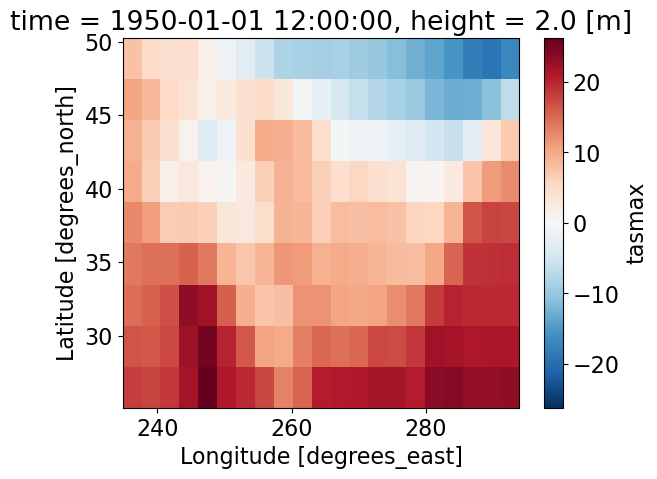

In [10]:
conus_t['heat']['ghg'].tasmax[0].plot()

In [11]:
nc_mask = xr.open_dataset("/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/fx/sftlf/gn/v20190429/sftlf_fx_CanESM5_hist-nat_r1i1p1f1_gn.nc")
ocean_mask = nc_mask.sel(
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
ocean_mask_conus = np.ma.masked_equal(ocean_mask.variables["sftlf"], 0)
ocean_mask_conus_tmax = np.broadcast_to(ocean_mask_conus.mask, conus_t["heat"]["all"].tasmax.shape)

In [12]:
# Bring this to full (time, lat, lon) for tasmax in the "all" scenario:
heat_all_da = conus_t["heat"]["all"].tasmax  # DataArray, shape (time, lat, lon)
ocean_mask_conus_tmax = np.broadcast_to(
    ocean_mask_conus.mask, heat_all_da.shape
)  # bool mask, same shape as tasmax

In [13]:
ocean_mask = nc_mask.sel(
    lat=slice(bottom, top),
    lon=slice(left, right),
)

# 2-D land mask: True on land, False on ocean
land_mask_2d = ocean_mask["sftlf"].values > 0

# Example shape reference
heat_ref = conus_t["heat"]["all"].tasmax.values  # (time, lat, lon)

# 3-D ocean mask: True on ocean, False on land
ocean_mask_3d = np.broadcast_to(~land_mask_2d, heat_ref.shape)


# -----------------------------
# 2. Thresholds
# -----------------------------
th = {
    "heat": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
    "cold": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
}

for sce in scenarios:
    heat_arr = conus_t["heat"][sce].tasmax.values   # (time, lat, lon)
    cold_arr = conus_t["cold"][sce].tasmin.values   # (time, lat, lon)

    # Convert ocean to NaN for percentile calculations
    heat_land = np.where(ocean_mask_3d, np.nan, heat_arr)
    cold_land = np.where(ocean_mask_3d, np.nan, cold_arr)

    # US-wide thresholds over all CONUS land points
    th["heat"]["us"][sce] = np.nanpercentile(heat_land, 99)
    th["cold"]["us"][sce] = np.nanpercentile(cold_land, 1)

    # Gridpoint thresholds over time
    th_grid_heat = np.nanpercentile(heat_land, 99, axis=0)   # (lat, lon)
    th_grid_cold = np.nanpercentile(cold_land, 1, axis=0)    # (lat, lon)

    # Mask ocean grid points
    th["heat"]["grid"][sce] = np.ma.array(th_grid_heat, mask=~land_mask_2d)
    th["cold"]["grid"][sce] = np.ma.array(th_grid_cold, mask=~land_mask_2d)


# -----------------------------
# 3. Extreme-day boolean arrays
# -----------------------------
for sce in scenarios:
    for ext in temp_ext:
        if ext == "heat":
            arr = conus_t[ext][sce].tasmax.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked >= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked >= th[ext]["grid"]["nat"]

        elif ext == "cold":
            arr = conus_t[ext][sce].tasmin.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked <= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked <= th[ext]["grid"]["nat"]




/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [14]:
th["heat"]["us"]

{'all': 42.019086608886724, 'nat': 41.43147064208985, 'ghg': 42.91197143554689}

In [15]:
th["cold"]["us"]

{'all': -29.347003784179687,
 'nat': -29.73101516723633,
 'ghg': -26.10977249145508}

## Read th directly save time to compute every time

In [18]:
if False:
    # Save
    with open("th.pkl", "wb") as f:
        pickle.dump(th, f)

In [19]:
if False:
    # Load
    with open("th.pkl", "rb") as f:
        th = pickle.load(f)

In [20]:
# -----------------------------
# 4. Yearly counts
# -----------------------------
days_per_year = 365
start_year = 1950
yrs = np.array(range(start_year, 2006))
for sce in scenarios:
    for ext in temp_ext:
        count_days_sep = np.zeros((len(yrs), 2))
        count_days_comp = np.zeros((len(yrs), 2))

        # masked array: (year, lat, lon)
        yearly_grid_counts = np.ma.masked_all((len(yrs), land_mask_2d.shape[0], land_mask_2d.shape[1]))

        for idx, yr in enumerate(yrs):
            i0 = idx * days_per_year
            i1 = (idx + 1) * days_per_year

            sep_slice = th[ext]["sep"][sce][i0:i1, :, :]
            comp_slice = th[ext]["comp"][sce][i0:i1, :, :]

            count_days_sep[idx, 0] = yr
            count_days_sep[idx, 1] = np.ma.sum(sep_slice)

            count_days_comp[idx, 0] = yr
            count_days_comp[idx, 1] = np.ma.sum(comp_slice)

            yearly_grid_counts[idx, :, :] = np.ma.sum(comp_slice, axis=0)

        th[ext]["day_sep"][sce] = count_days_sep
        th[ext]["day_comp"][sce] = count_days_comp
        th[ext]["hdays_py"][sce] = yearly_grid_counts

In [21]:
th["heat"]["grid"][sce]

masked_array(
  data=[[--, --, --, 31.4714298248291, 41.31427764892578,
         40.36850357055664, 37.03117370605469, 39.00402069091797,
         41.6177864074707, 42.081905364990234, 31.238935470581055, --,
         --, --, 30.547880172729492, 31.969594955444336,
         30.183107376098633, --, --, --, --],
        [--, --, --, 37.05695724487305, 51.038909912109375,
         43.872840881347656, 40.26963424682617, 42.50277328491211,
         44.949100494384766, 43.03655242919922, 37.4315071105957,
         34.00825881958008, 32.83817672729492, 31.59644317626953,
         32.86653518676758, 34.53702163696289, 30.179773330688477, --,
         --, --, --],
        [--, --, 32.7351188659668, 49.45396041870117, 51.171478271484375,
         44.431026458740234, 42.99946594238281, 44.23162078857422,
         44.082252502441406, 43.15346145629883, 42.75077819824219,
         41.73147201538086, 40.36814880371094, 38.52312469482422,
         38.096031188964844, 35.98591232299805, 31.61260032653

# plot

In [60]:
fig_size = (6,4.5)

In [23]:
lats_conus = ocean_mask.lat
lons_conus = ocean_mask.lon
#lats_conus = lats[geo_idx(bottom, lats):geo_idx(top, lats) + 1]
#lons_conus = lons[geo_idx(left, lons):geo_idx(right, lons) + 1]

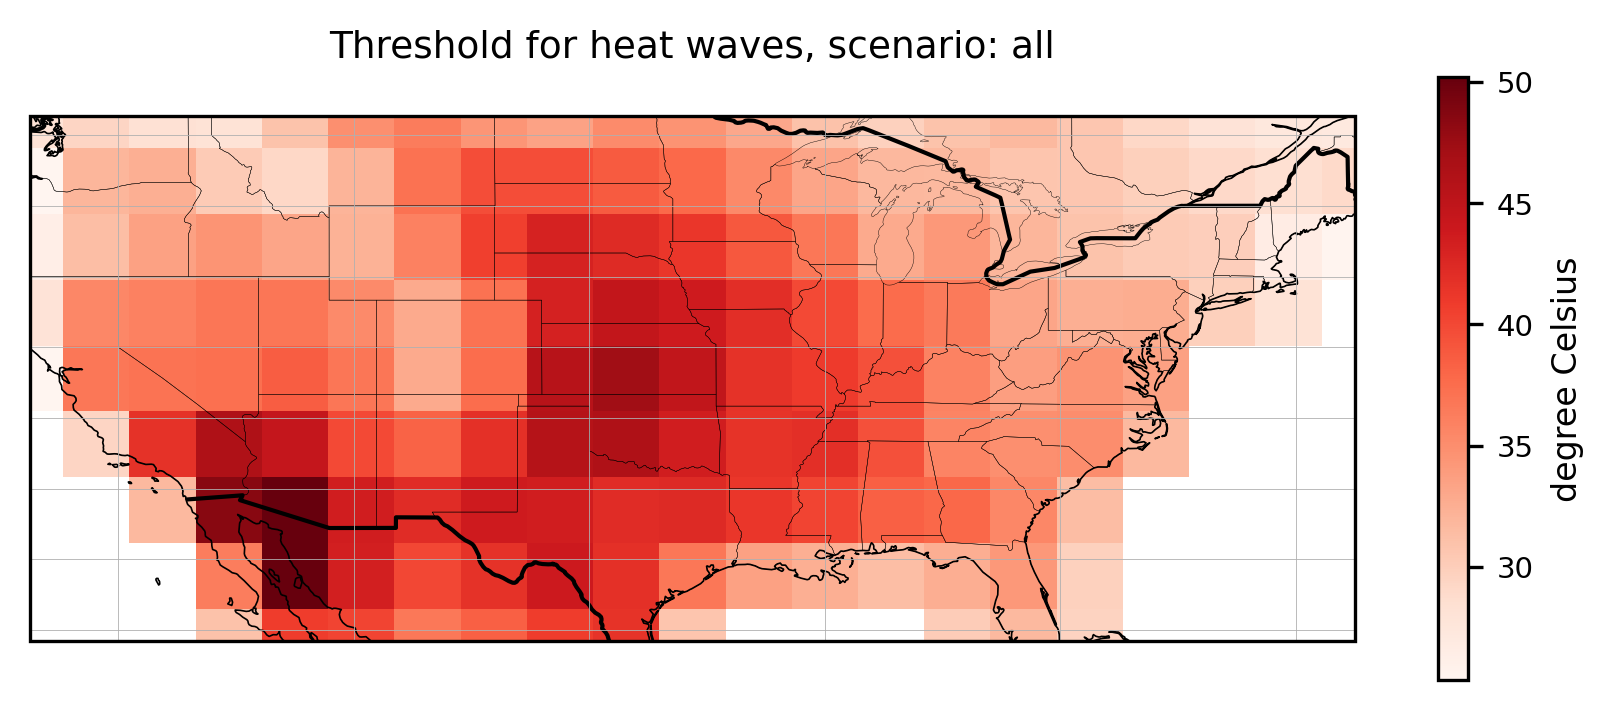

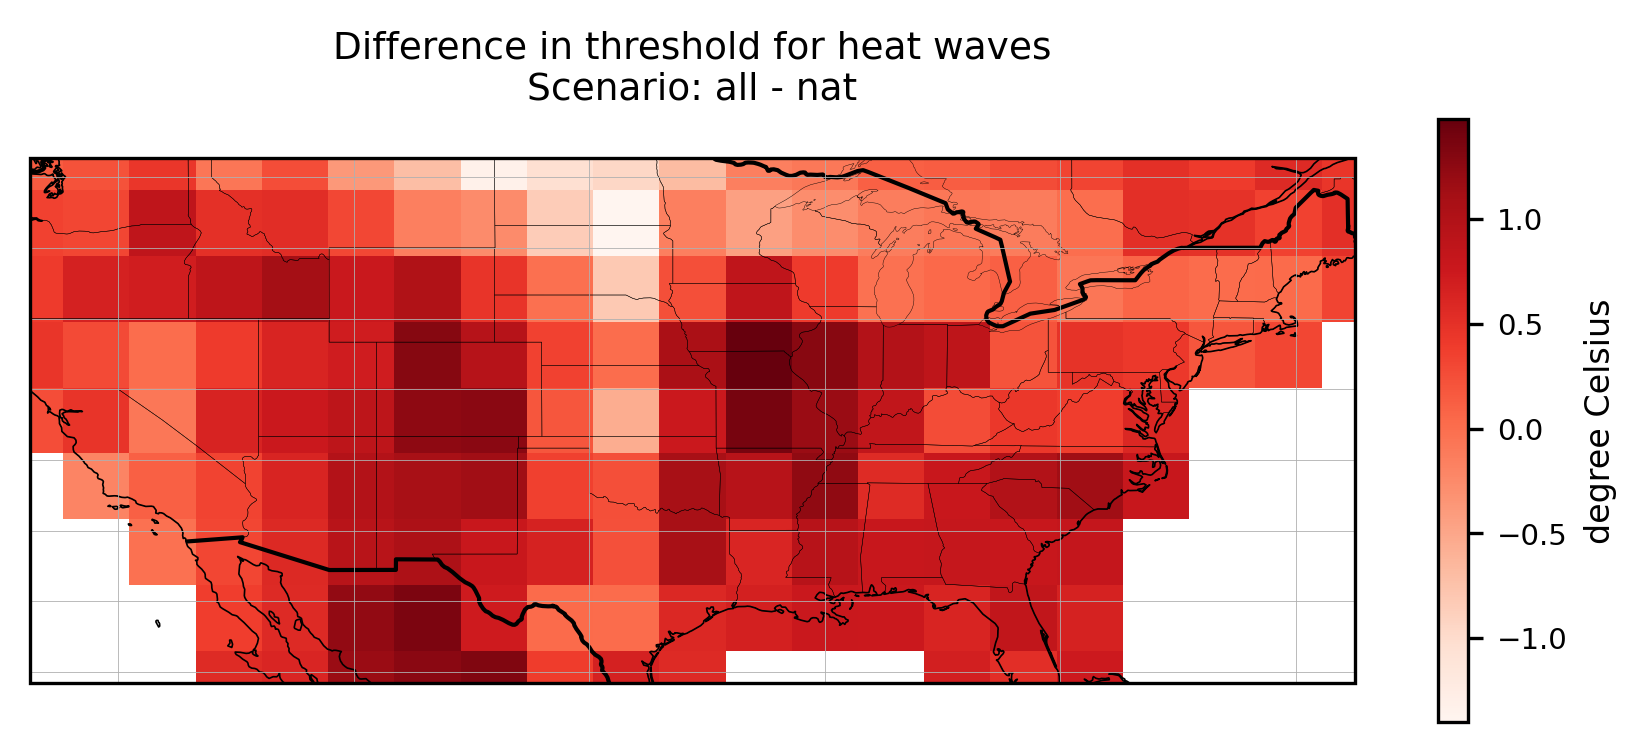

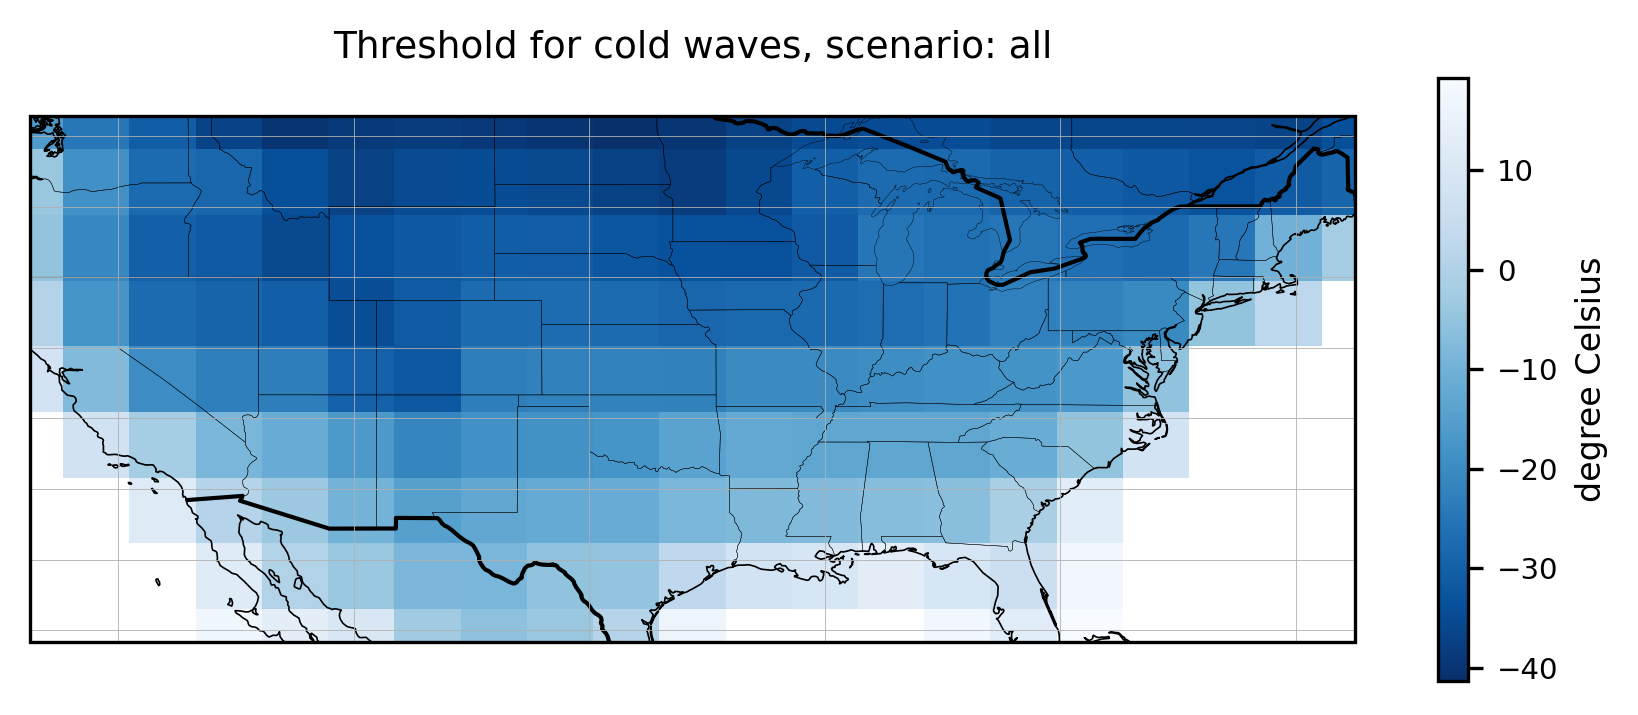

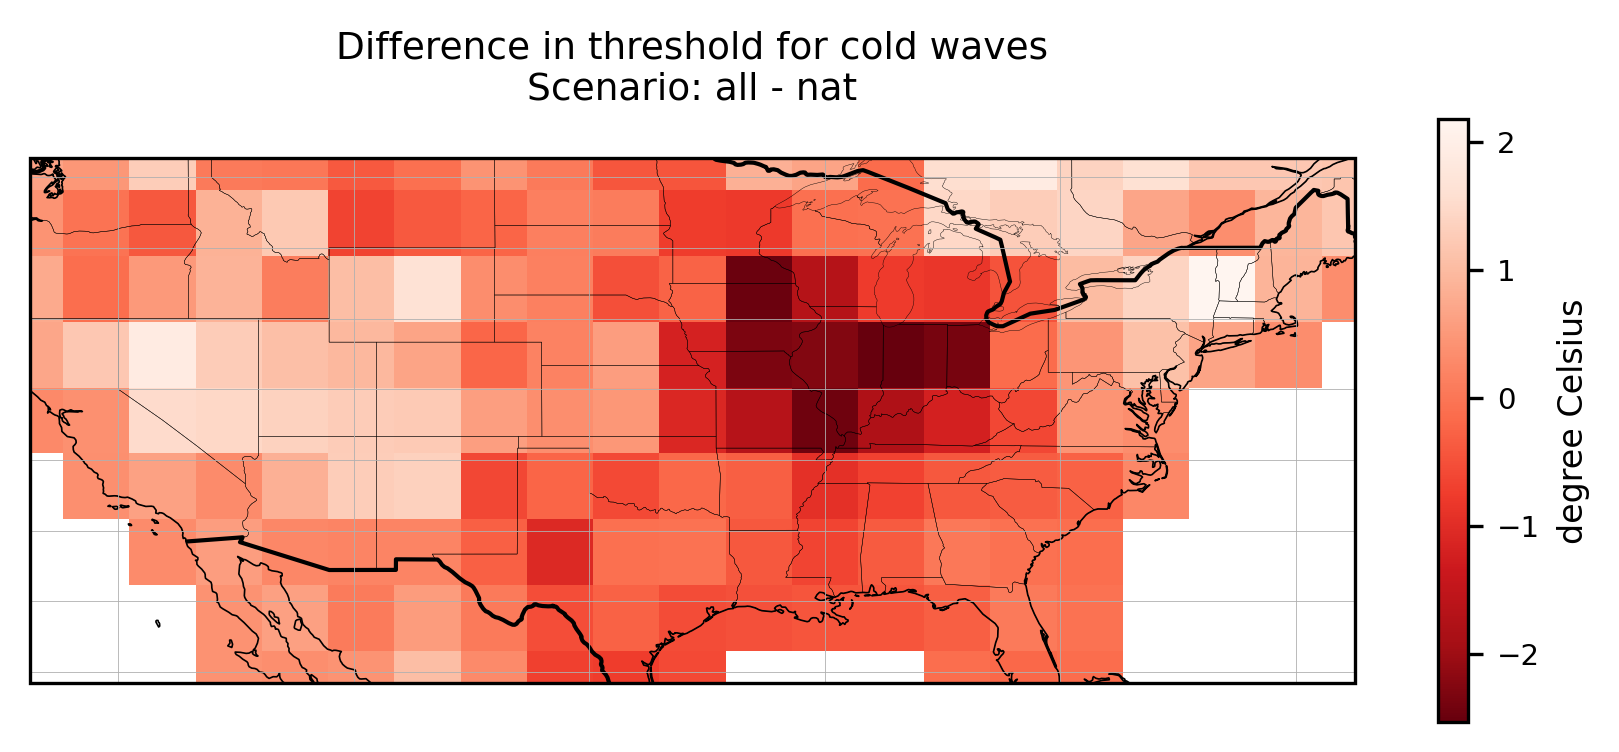

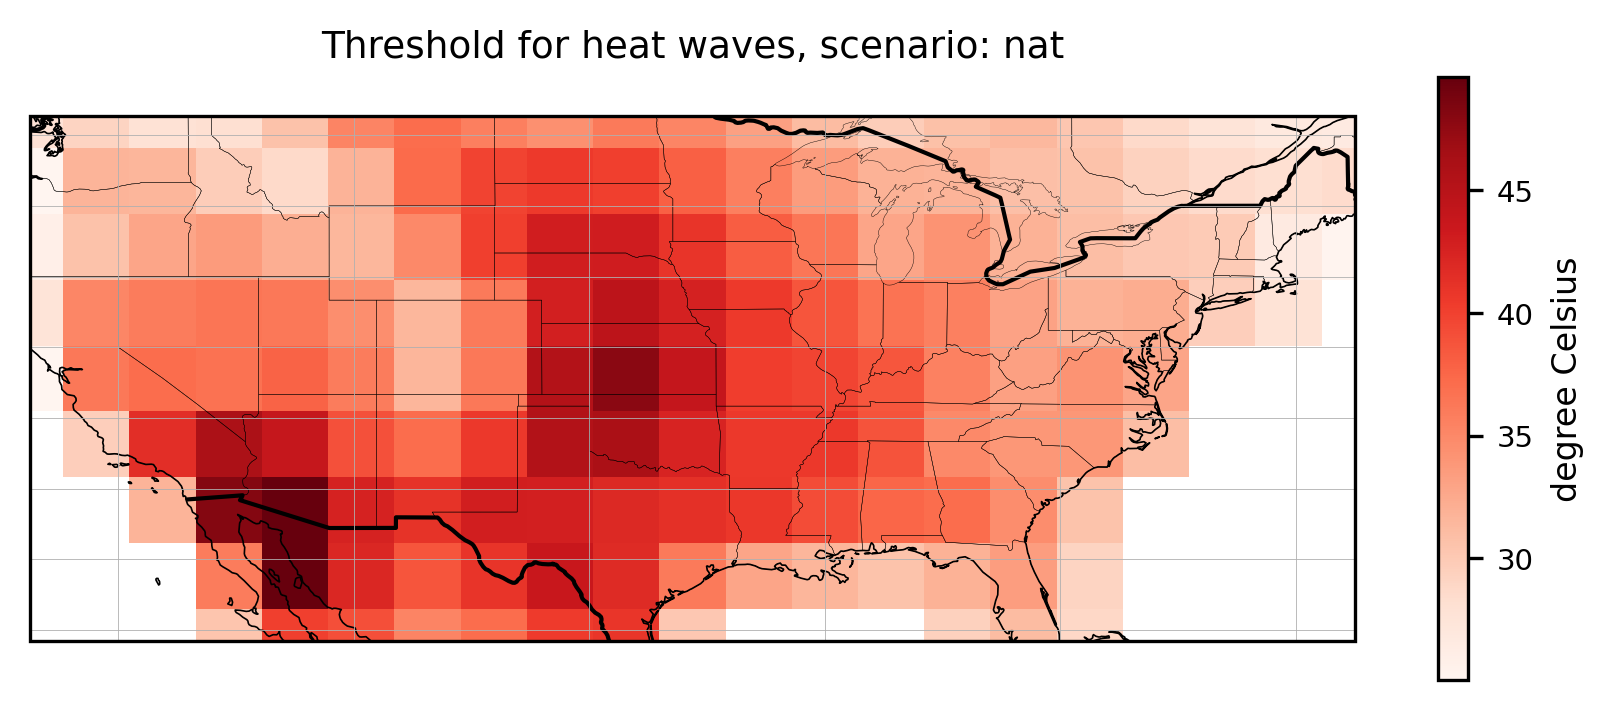

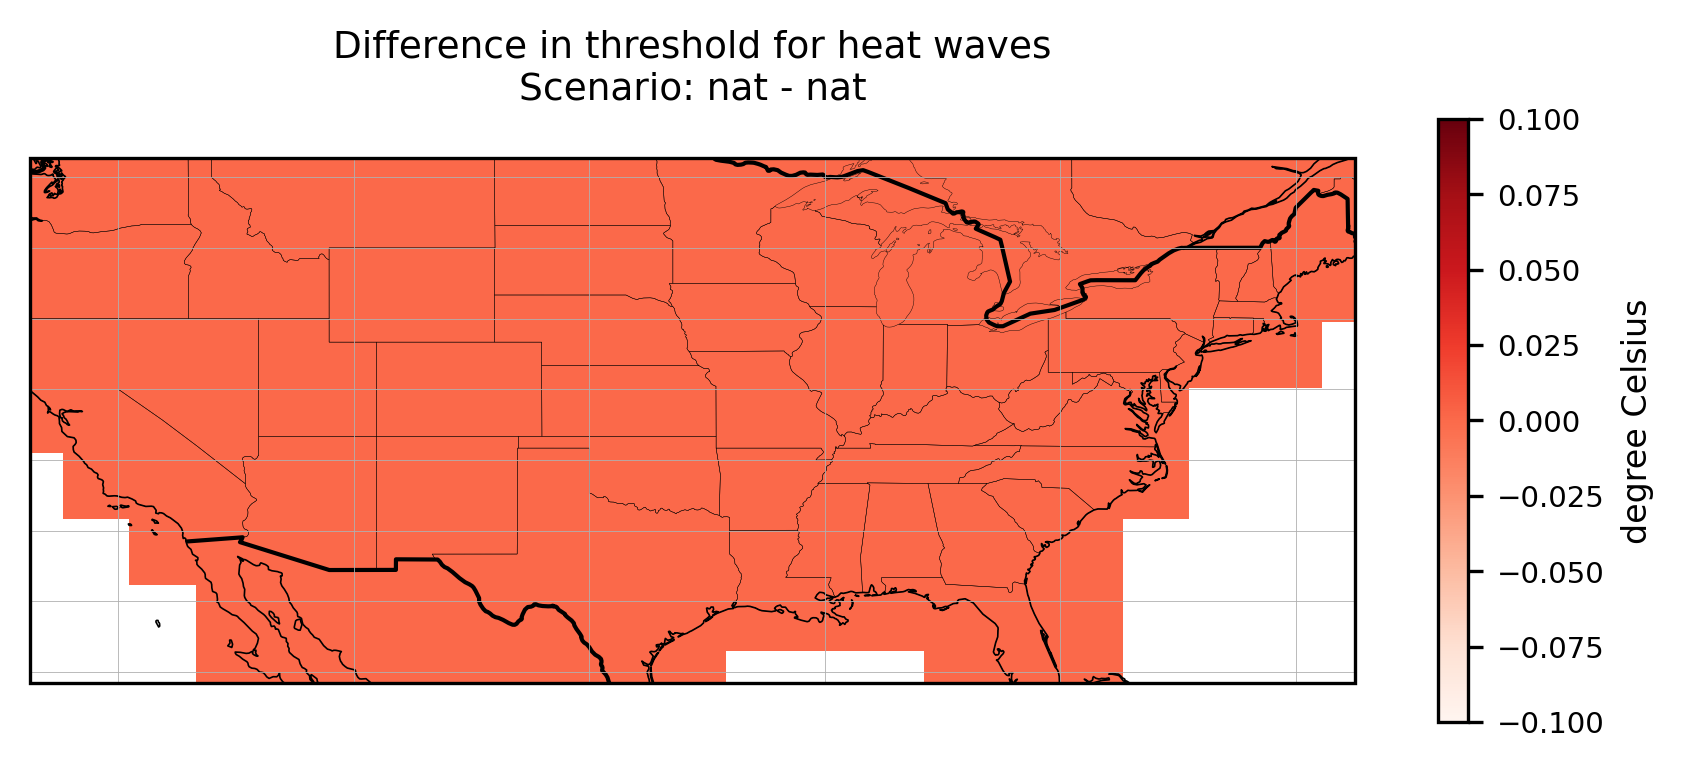

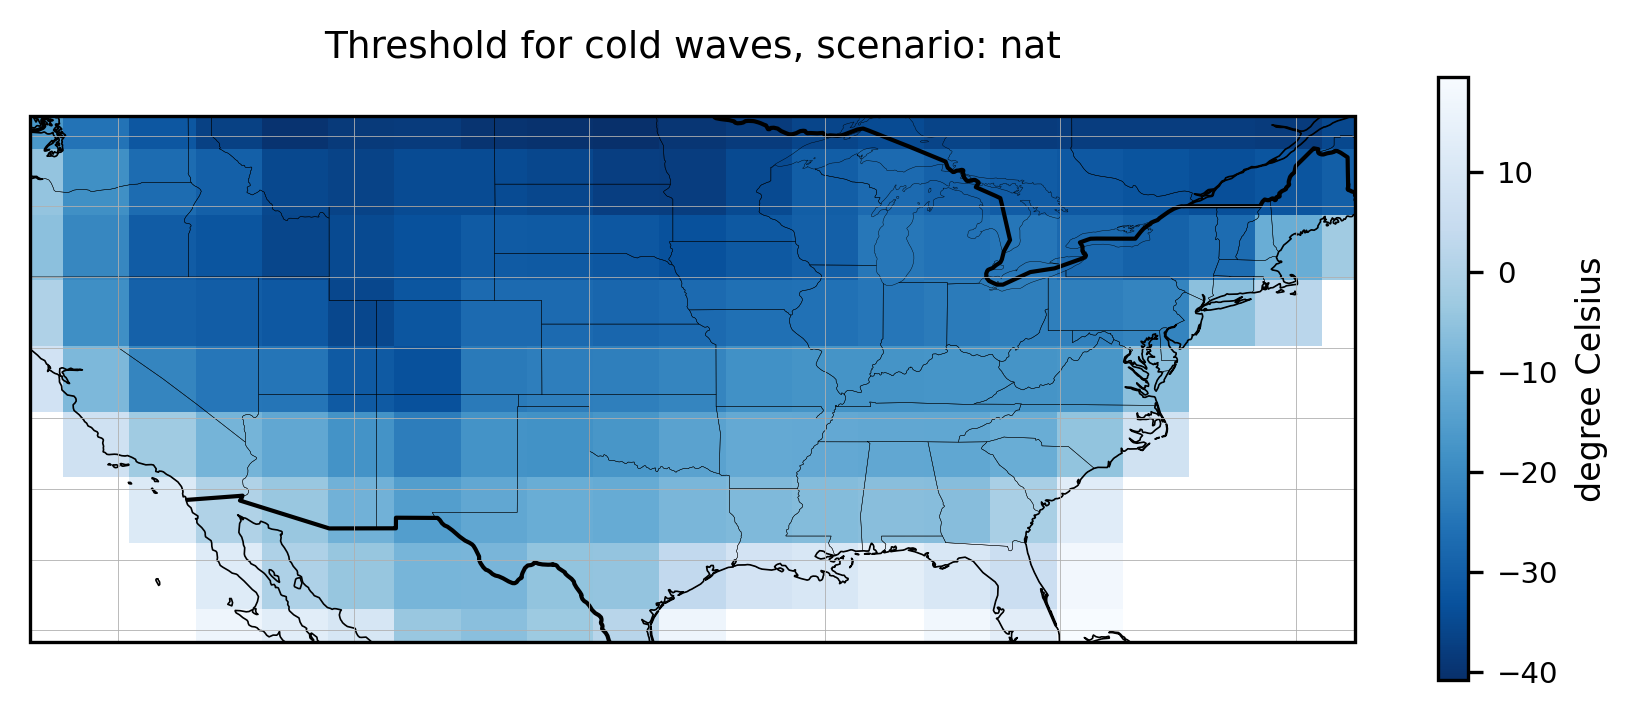

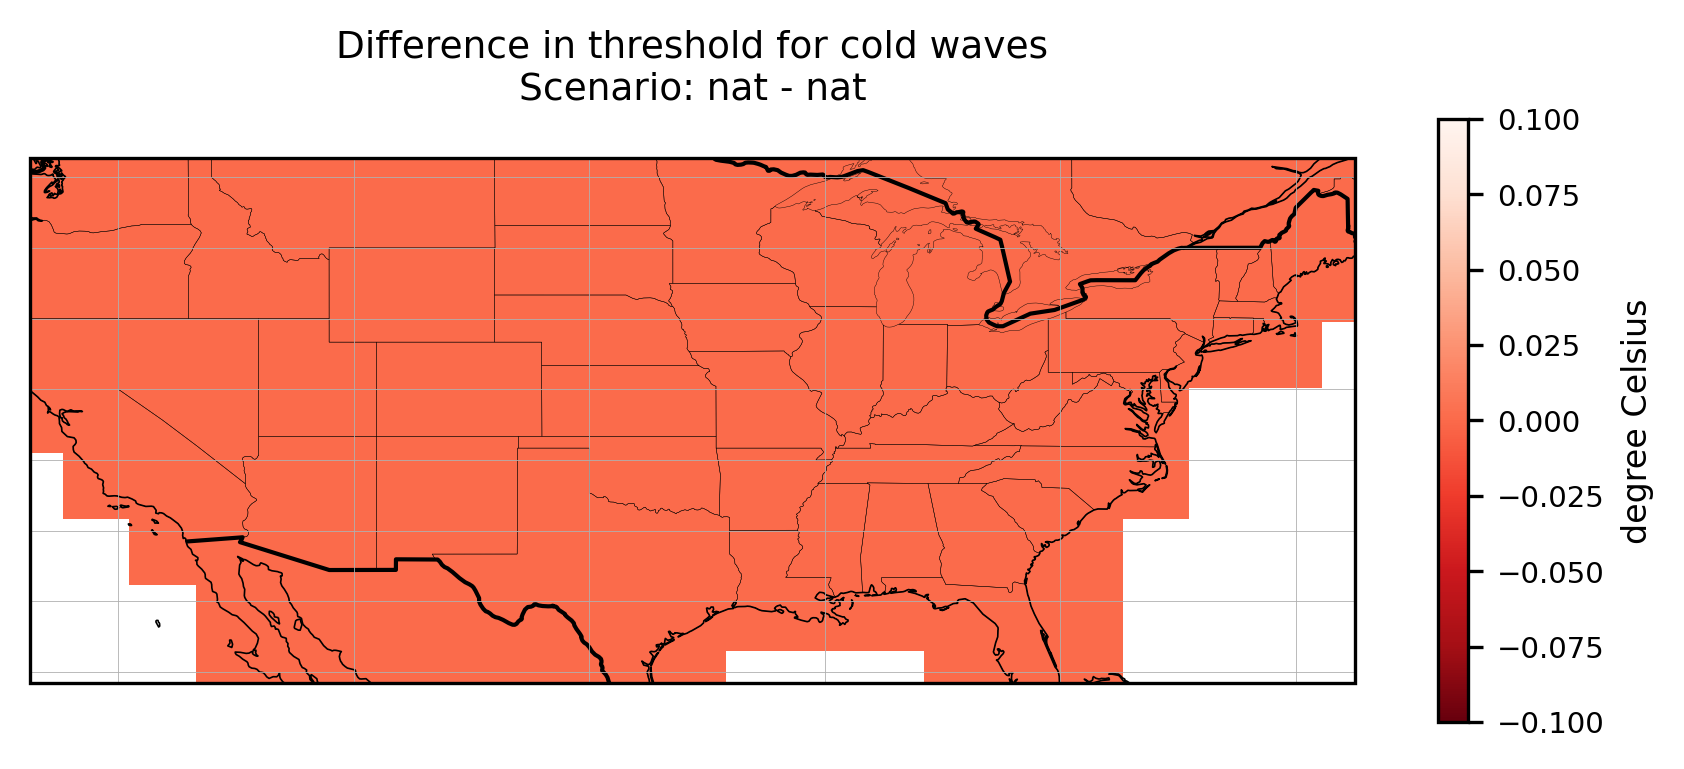

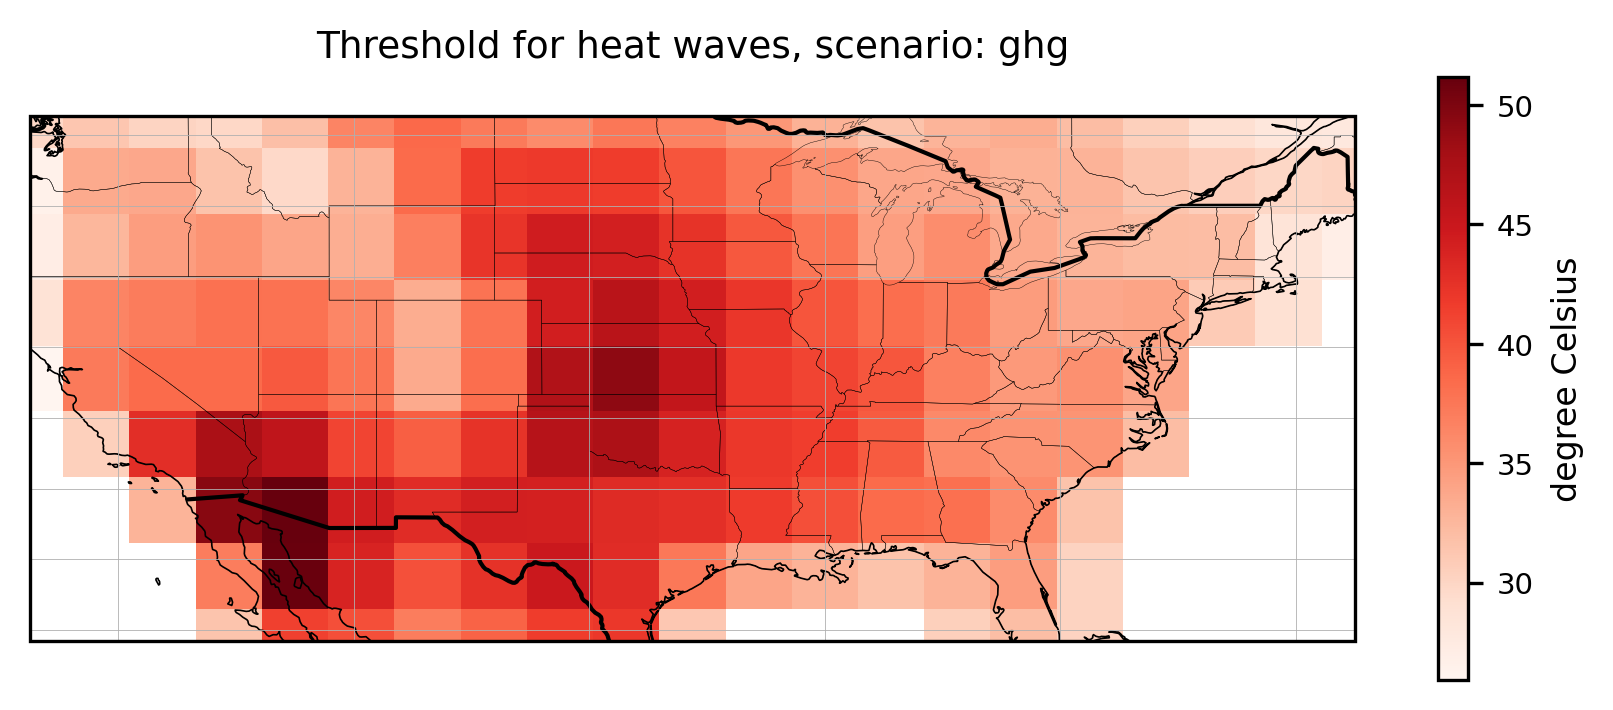

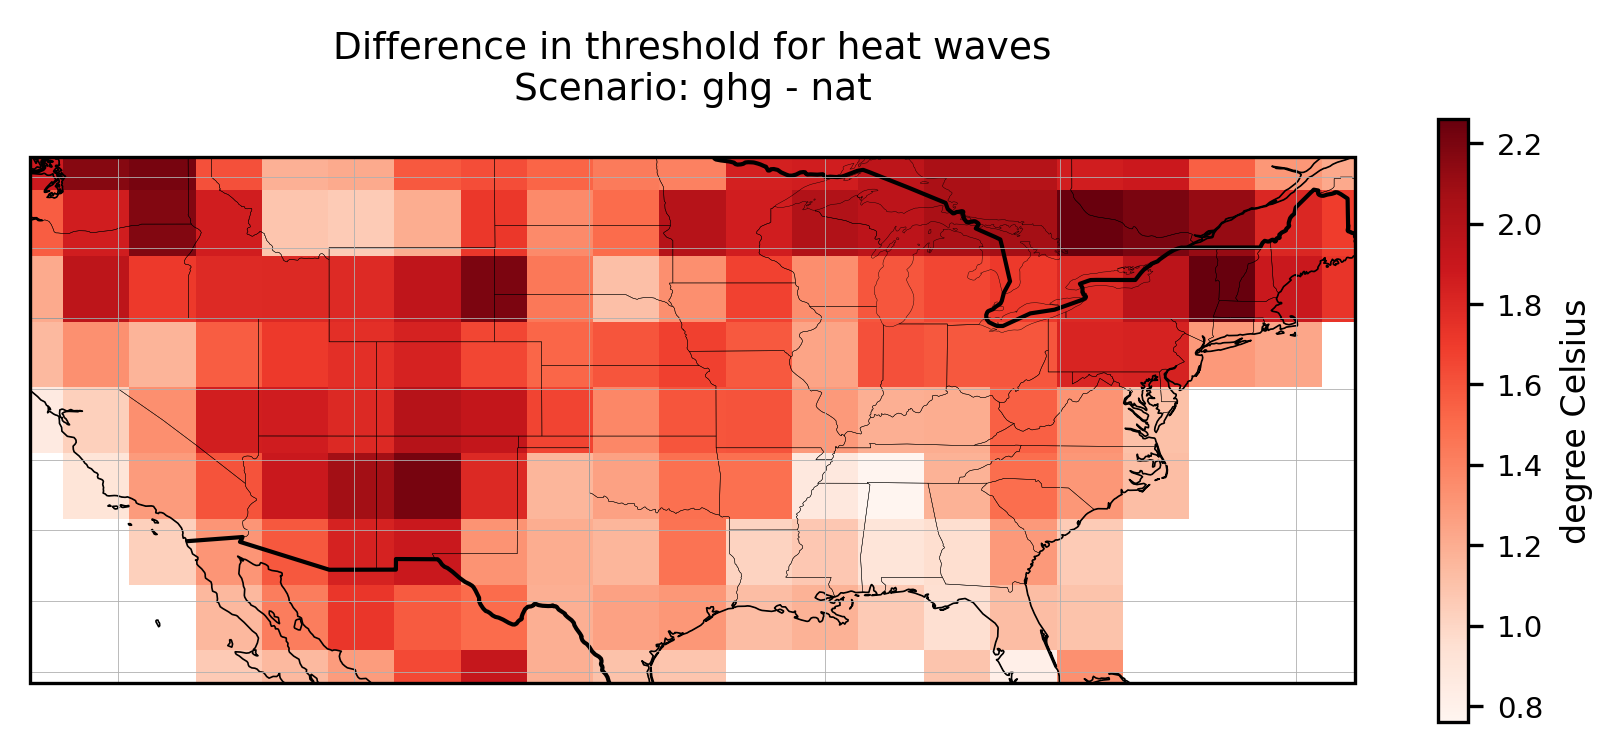

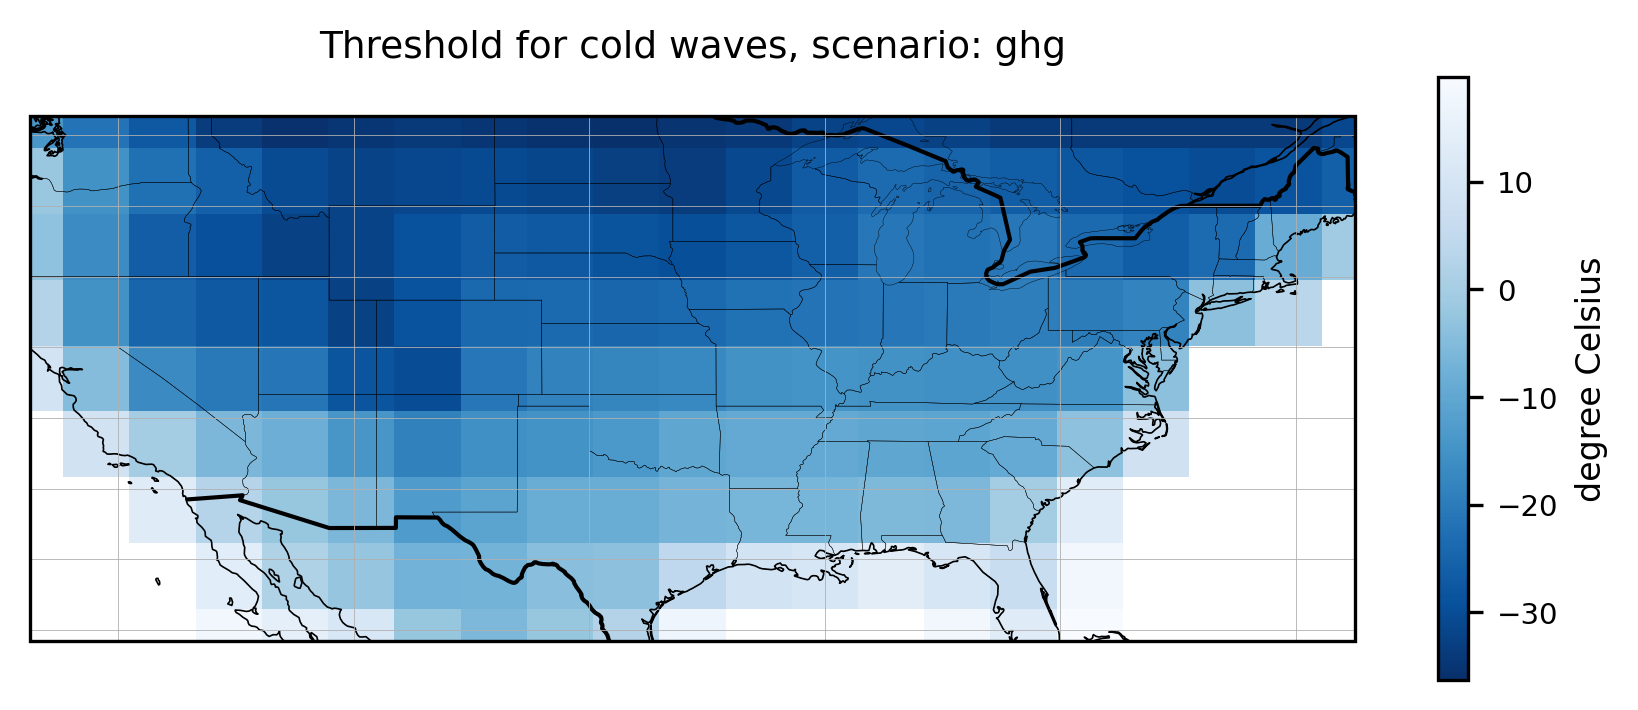

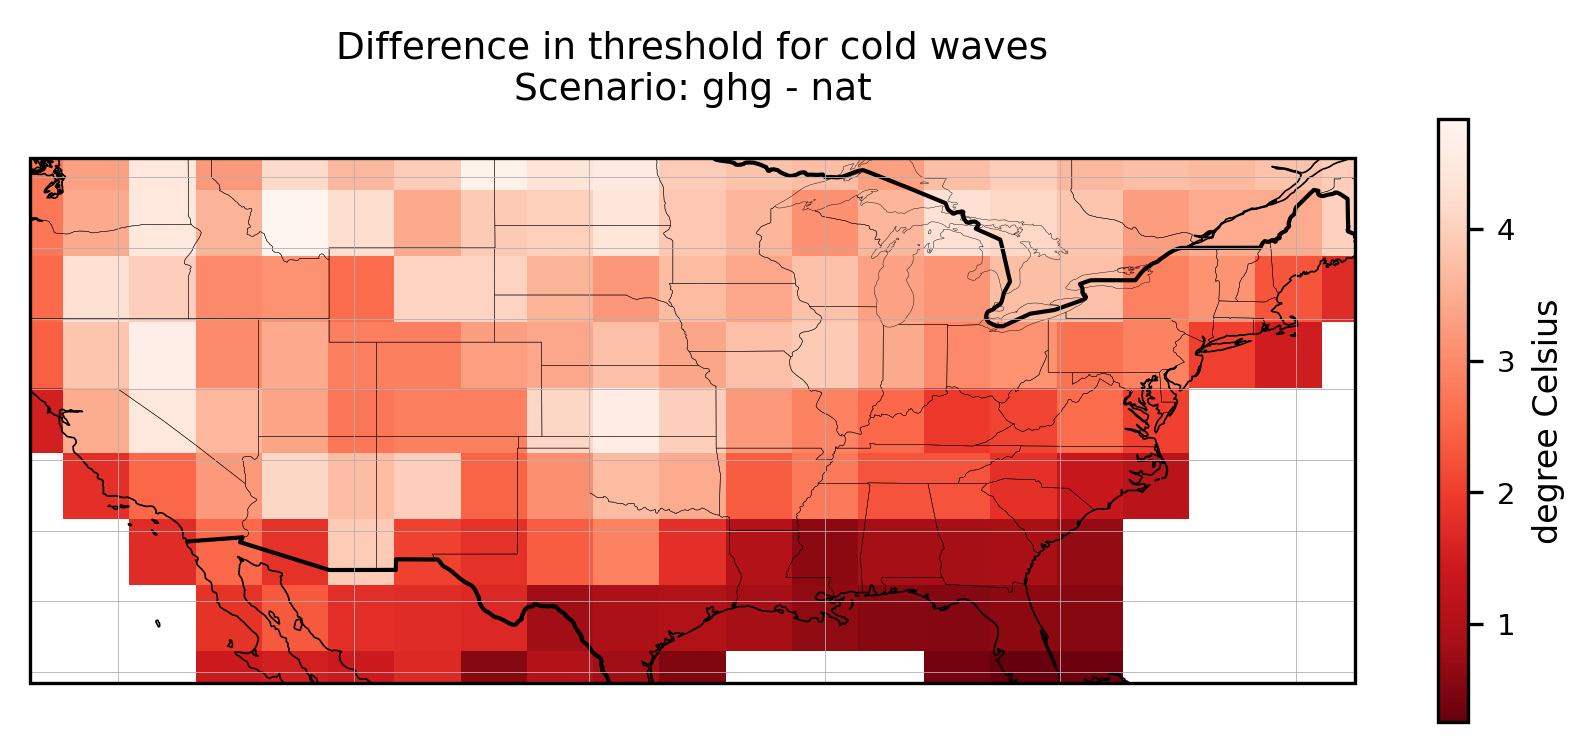

In [24]:
# Map from 'heat'/'cold' to label and colormaps
EXT_LABEL = {"heat": "heat waves", "cold": "cold waves"}
EXT_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Blues_r"]}
DIFF_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Reds_r"]}

# Smaller fonts to match your example
TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)



for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # --- Threshold map ---
        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            th[ext]["grid"][sce],
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax, shrink=0.5)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Threshold for {label}, scenario: {sce}\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_{ext}_{sce}.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

        # --- Difference map (scenario minus nat) ---
        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        diff = th[ext]["grid"][sce] - th[ext]["grid"]["nat"]

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff,
            transform=ccrs.PlateCarree(),
            cmap=DIFF_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax,shrink=0.5)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Difference in threshold for {label}\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_diff_{ext}_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

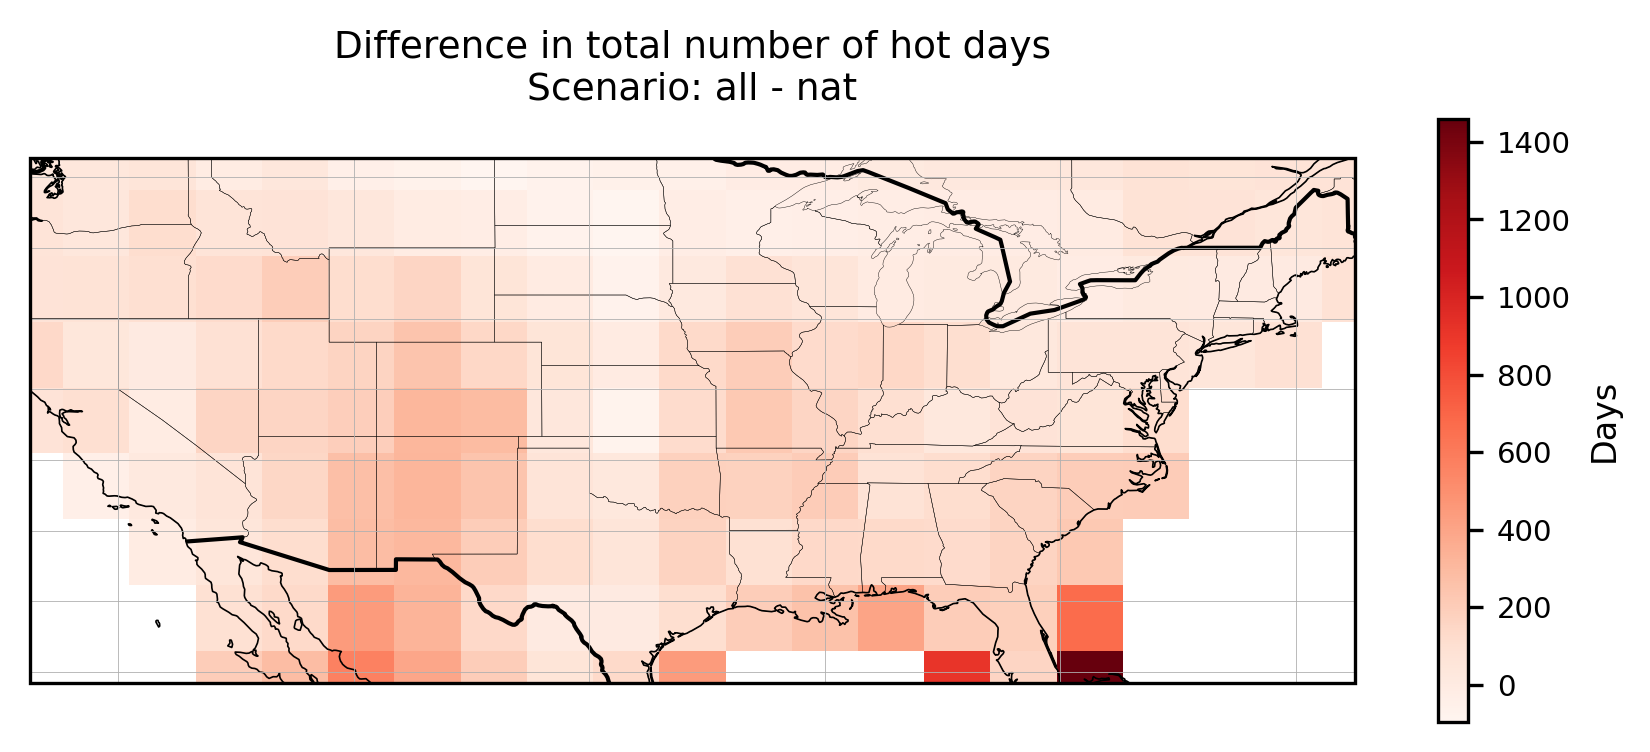

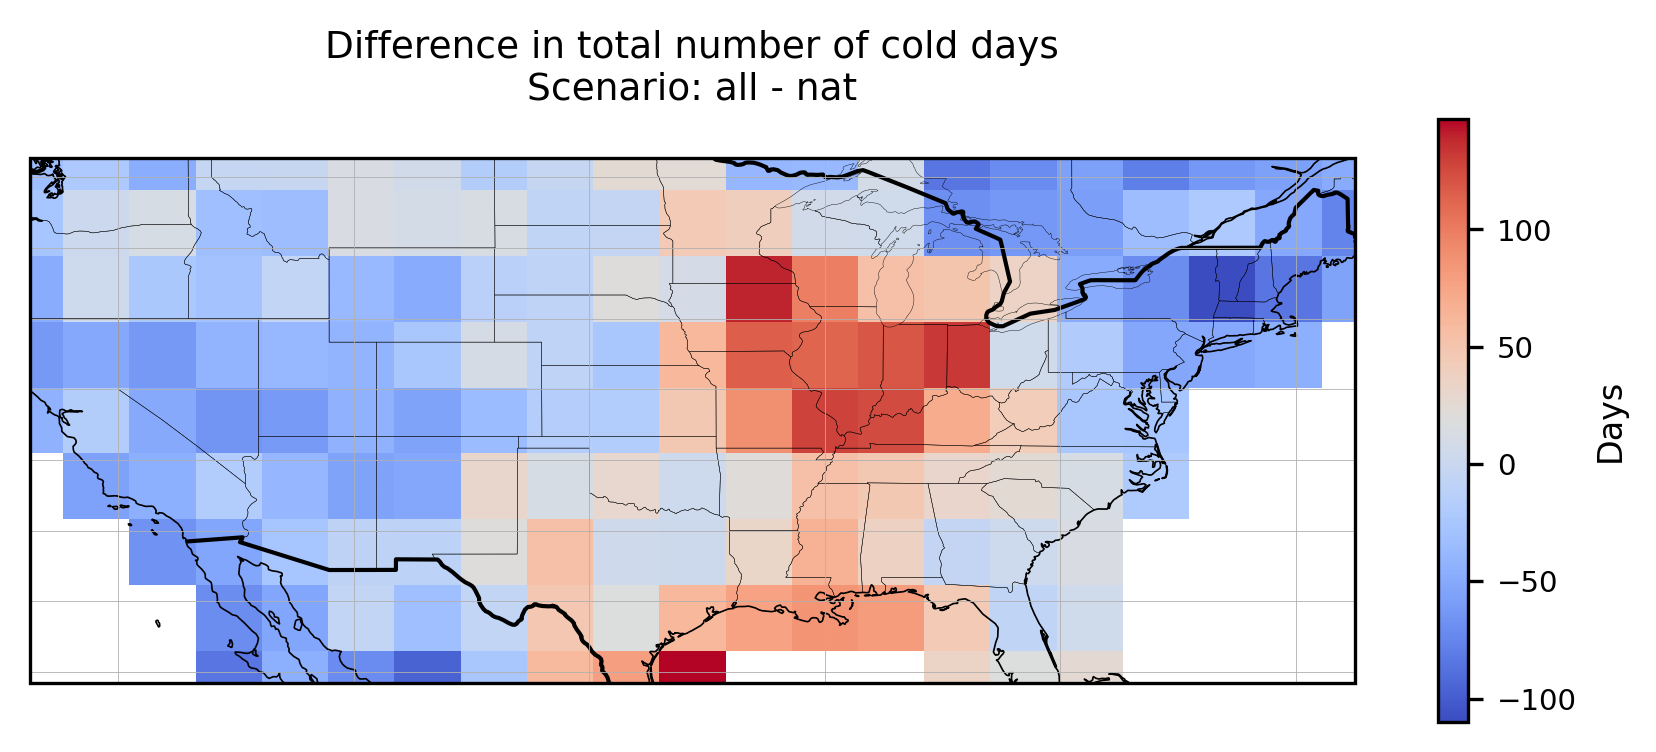

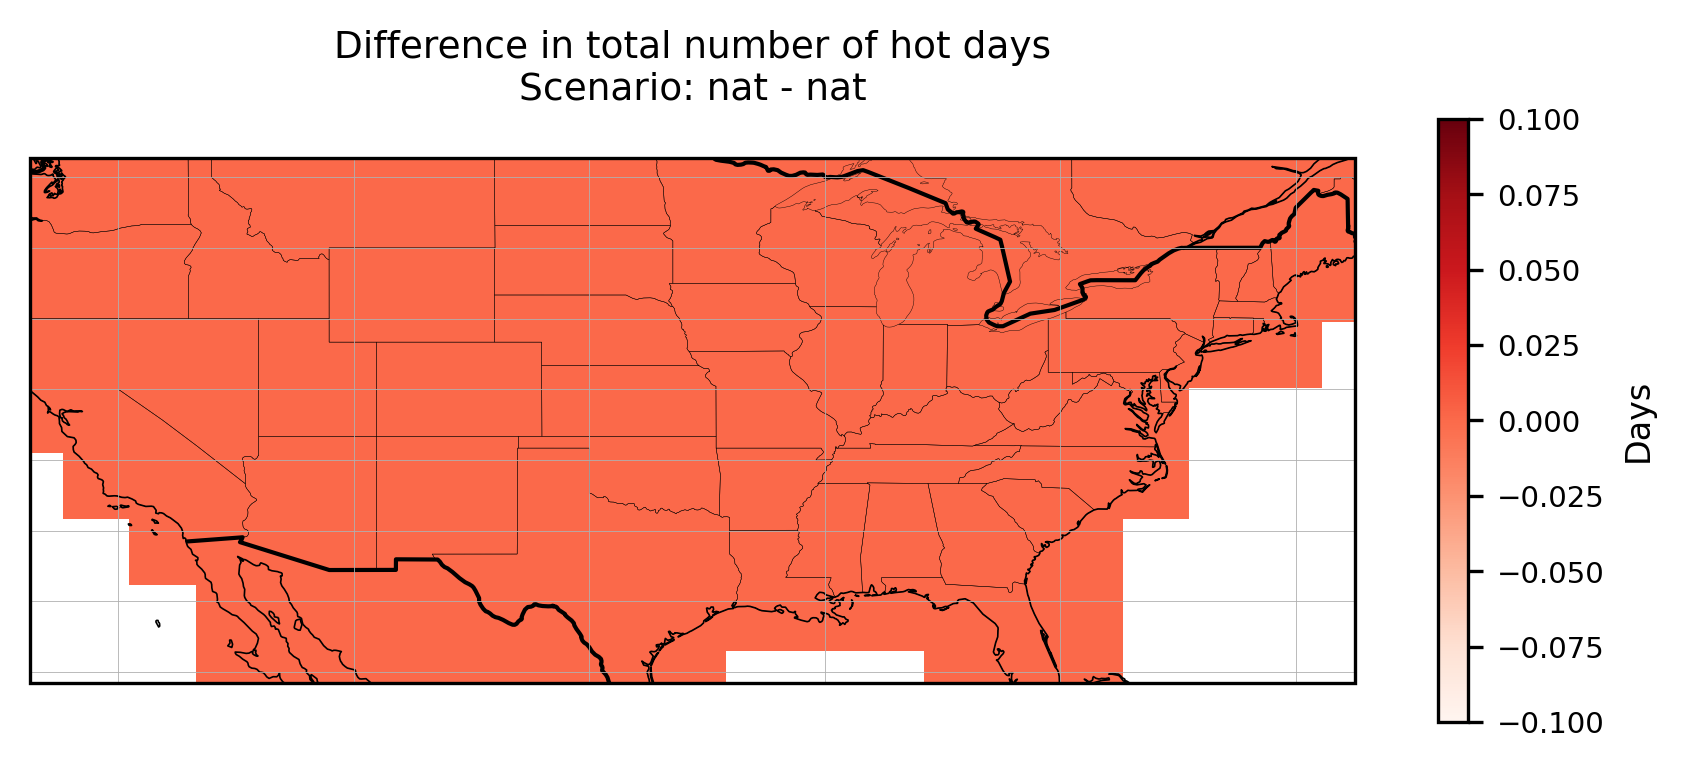

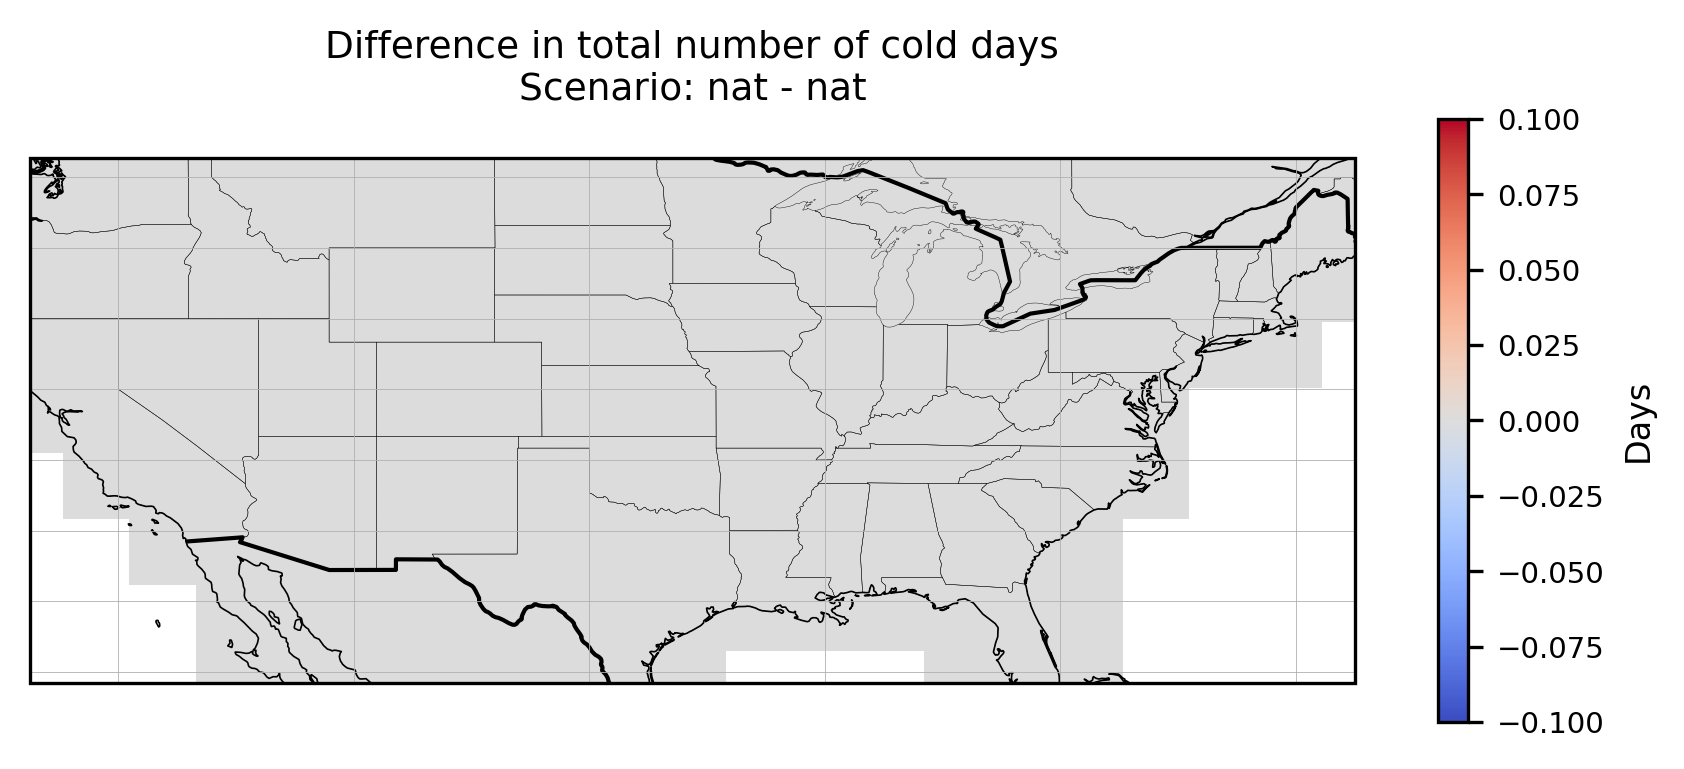

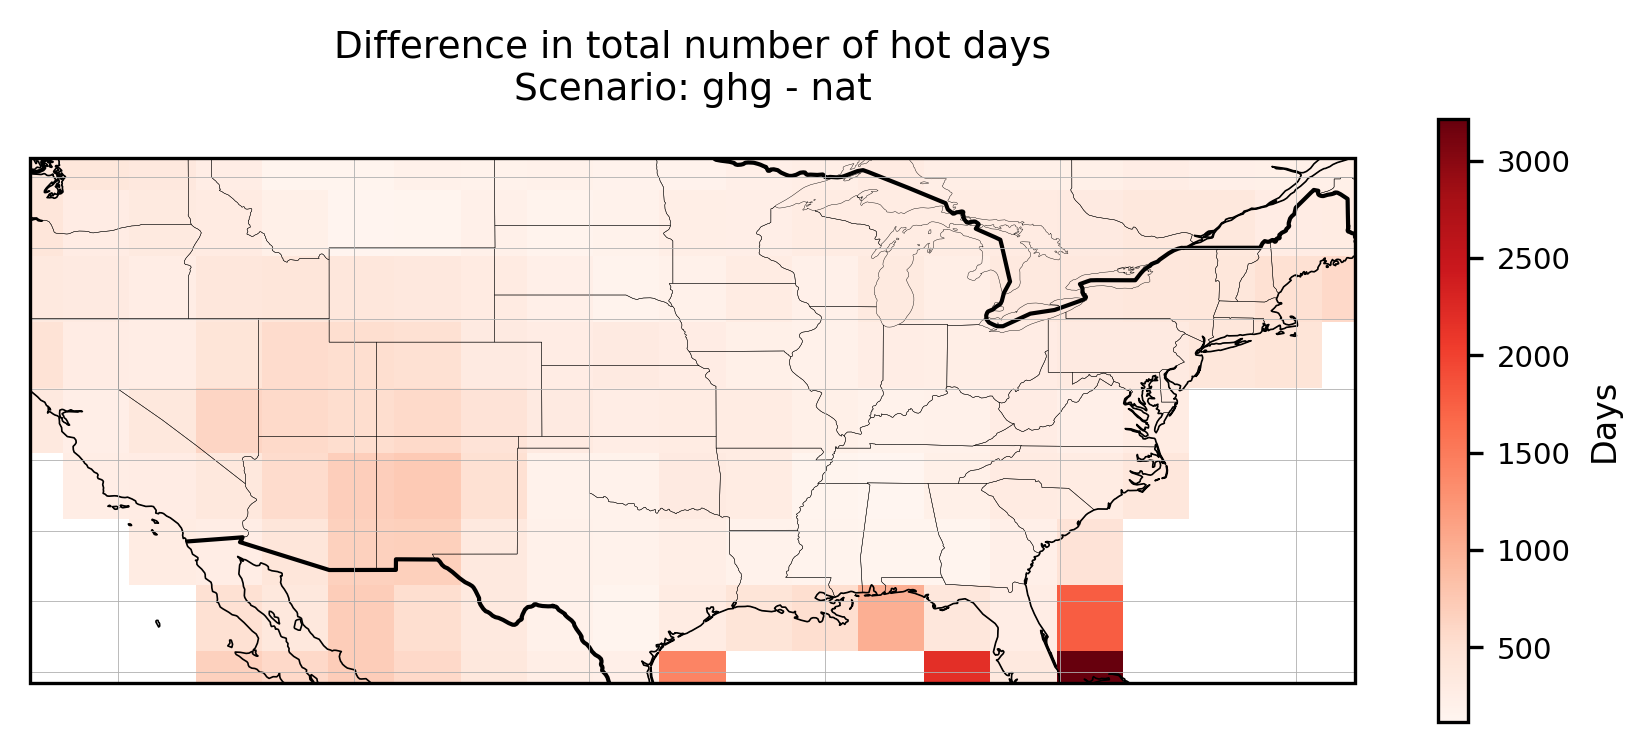

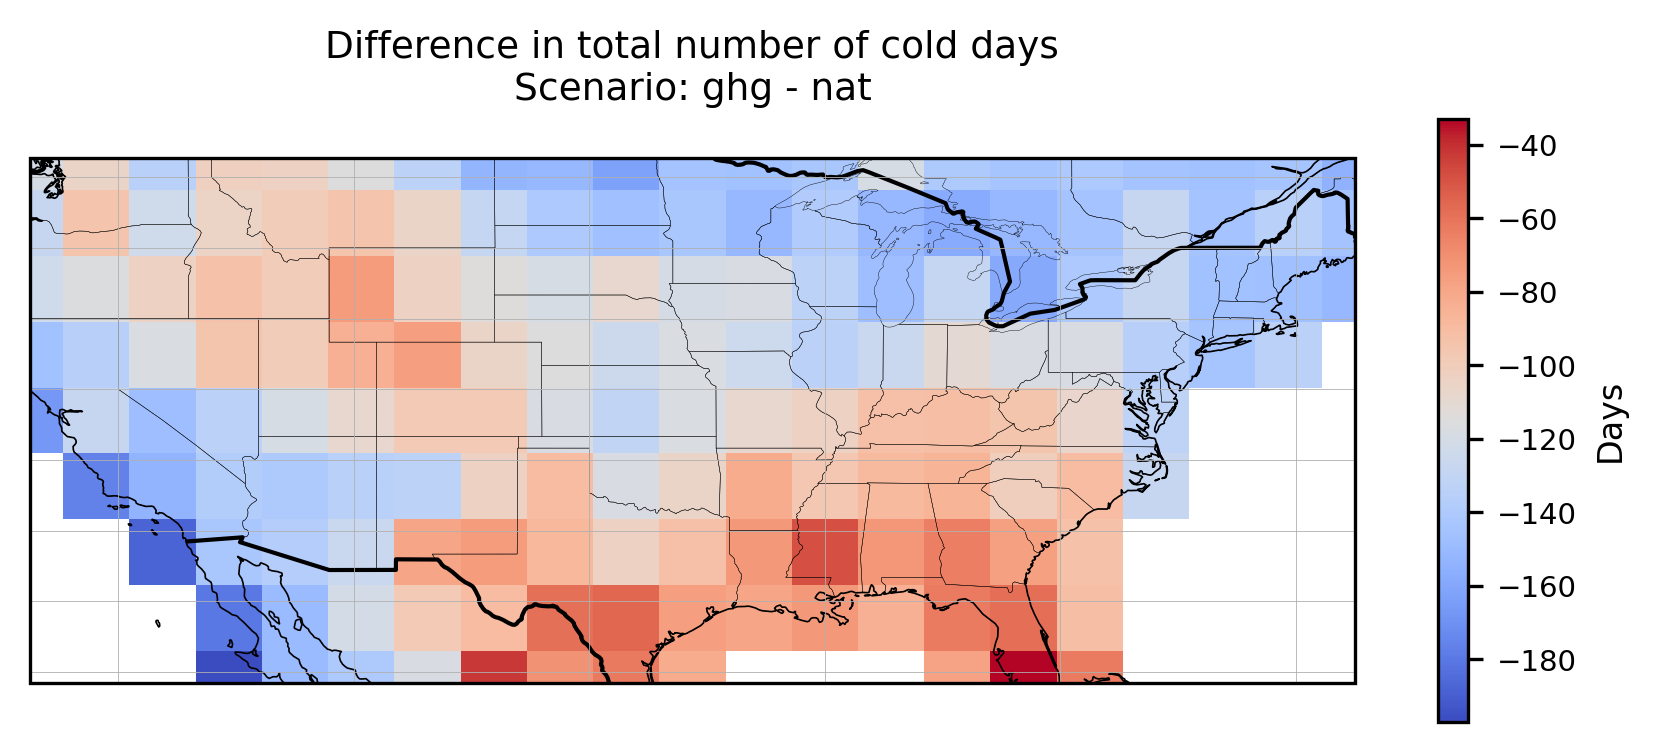

In [26]:

EXT_LABEL = {"heat": "hot", "cold": "cold"}
EXT_CMAP_TOTAL_DIFF = {
    "heat": mpl.colormaps["Reds"],
    "cold": mpl.colormaps["coolwarm"],
}

# Font sizes to match your example style
TITLE_FONTSIZE = 9     # try 8 if you want even smaller
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Spatial map of total increase in hot/cold days (scenario vs nat)
for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # Sum over years → total days per grid cell
        total_sce = np.sum(th[ext]["hdays_py"][sce], axis=0)     # (lat, lon)
        total_nat = np.sum(th[ext]["hdays_py"]["nat"], axis=0)   # (lat, lon)
        diff_days = total_sce - total_nat

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff_days,
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP_TOTAL_DIFF[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)

        # Axis ticks
        ax.tick_params(labelsize=AX_TICKSIZE)

        # Colorbar
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.5)
        cbar.ax.set_ylabel("Days", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        # Title
        ax.set_title(
            f"Difference in total number of {label} days\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"diff_{ext}_days_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

In [28]:
start_date

'1950-01-01'

In [29]:
if isinstance(start_date, str):
    start_year = int(start_date[:4])
    start_month = int(start_date[5:7])
    start_day = int(start_date[8:10])
else:
    start_month = start_date.month
    start_day = start_date.day

yrs_dt = [cftime.DatetimeNoLeap(int(yr), start_month, start_day) for yr in yrs]

In [38]:
th["heat"]["days_pr_stats"] = {}
th["cold"]["days_pr_stats"] = {}

for sce in scenarios:
    th["heat"]["days_pr_stats"][sce] = {}
    th["cold"]["days_pr_stats"][sce] = {}

    # Heat
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["heat"]["day_comp"][sce][:, 1]
    )
    th["heat"]["days_pr_stats"][sce]["slope"] = slope
    th["heat"]["days_pr_stats"][sce]["intercept"] = intercept
    th["heat"]["days_pr_stats"][sce]["rvalue"] = rvalue
    th["heat"]["days_pr_stats"][sce]["pvalue"] = pvalue
    th["heat"]["days_pr_stats"][sce]["stderr"] = stderr
    th["heat"]["days_pr_stats"][sce]["trend"] = slope * np.asarray(yrs) + intercept

    # Cold
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["cold"]["day_comp"][sce][:, 1]
    )
    th["cold"]["days_pr_stats"][sce]["slope"] = slope
    th["cold"]["days_pr_stats"][sce]["intercept"] = intercept
    th["cold"]["days_pr_stats"][sce]["rvalue"] = rvalue
    th["cold"]["days_pr_stats"][sce]["pvalue"] = pvalue
    th["cold"]["days_pr_stats"][sce]["stderr"] = stderr
    th["cold"]["days_pr_stats"][sce]["trend"] = slope * np.asarray(yrs) + intercept


In [41]:

title_fs = 10
label_fs = 10
tick_fs = 8
legend_fs = 8
line_fs = 0.7
trend_fs = 0.5

colors = {
    "nat": "b",
    "ghg": "k",
    "all": "r",
}

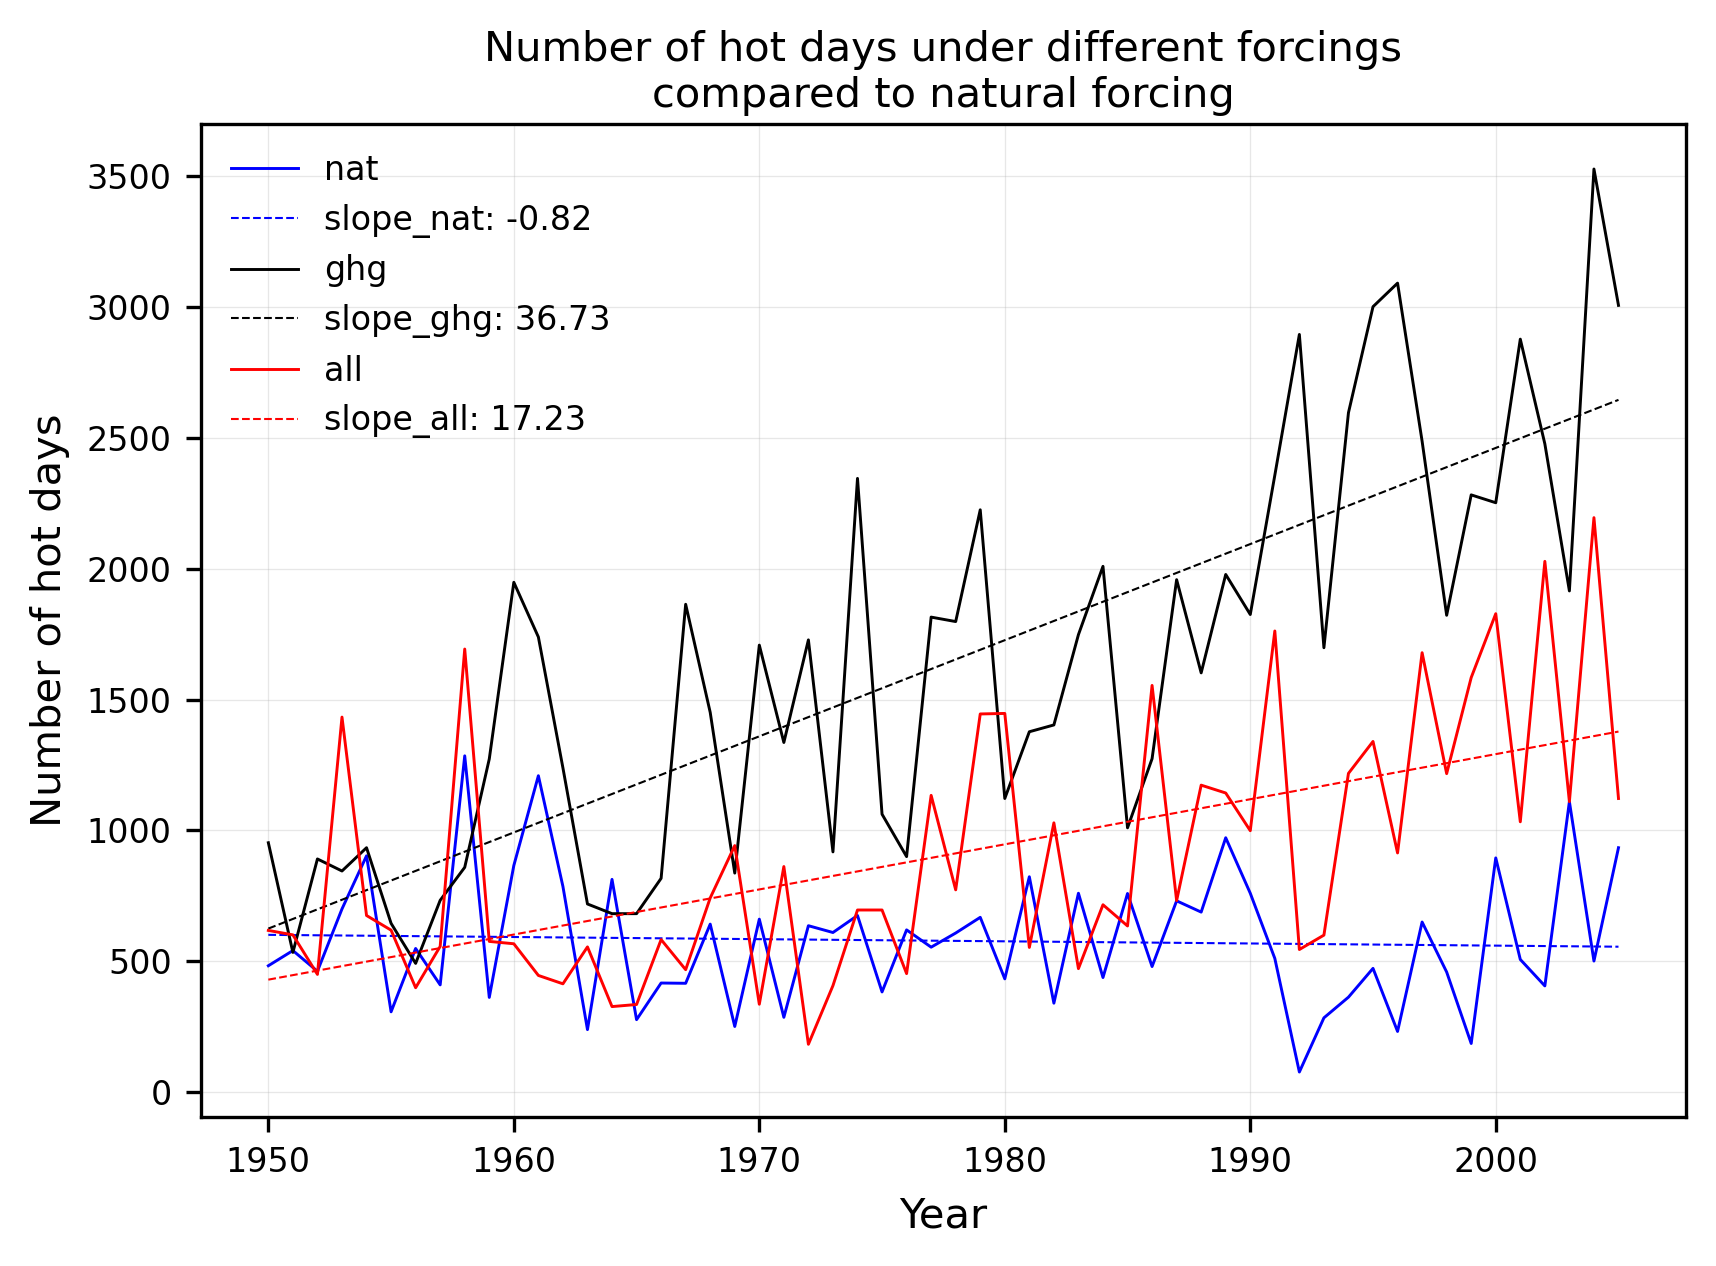

In [42]:
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["heat"]["day_comp"][sce][:, 1],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["heat"]["days_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['heat']['days_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of hot days under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of hot days", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "hot_days_py.png"), bbox_inches="tight")
#plt.close(fig)


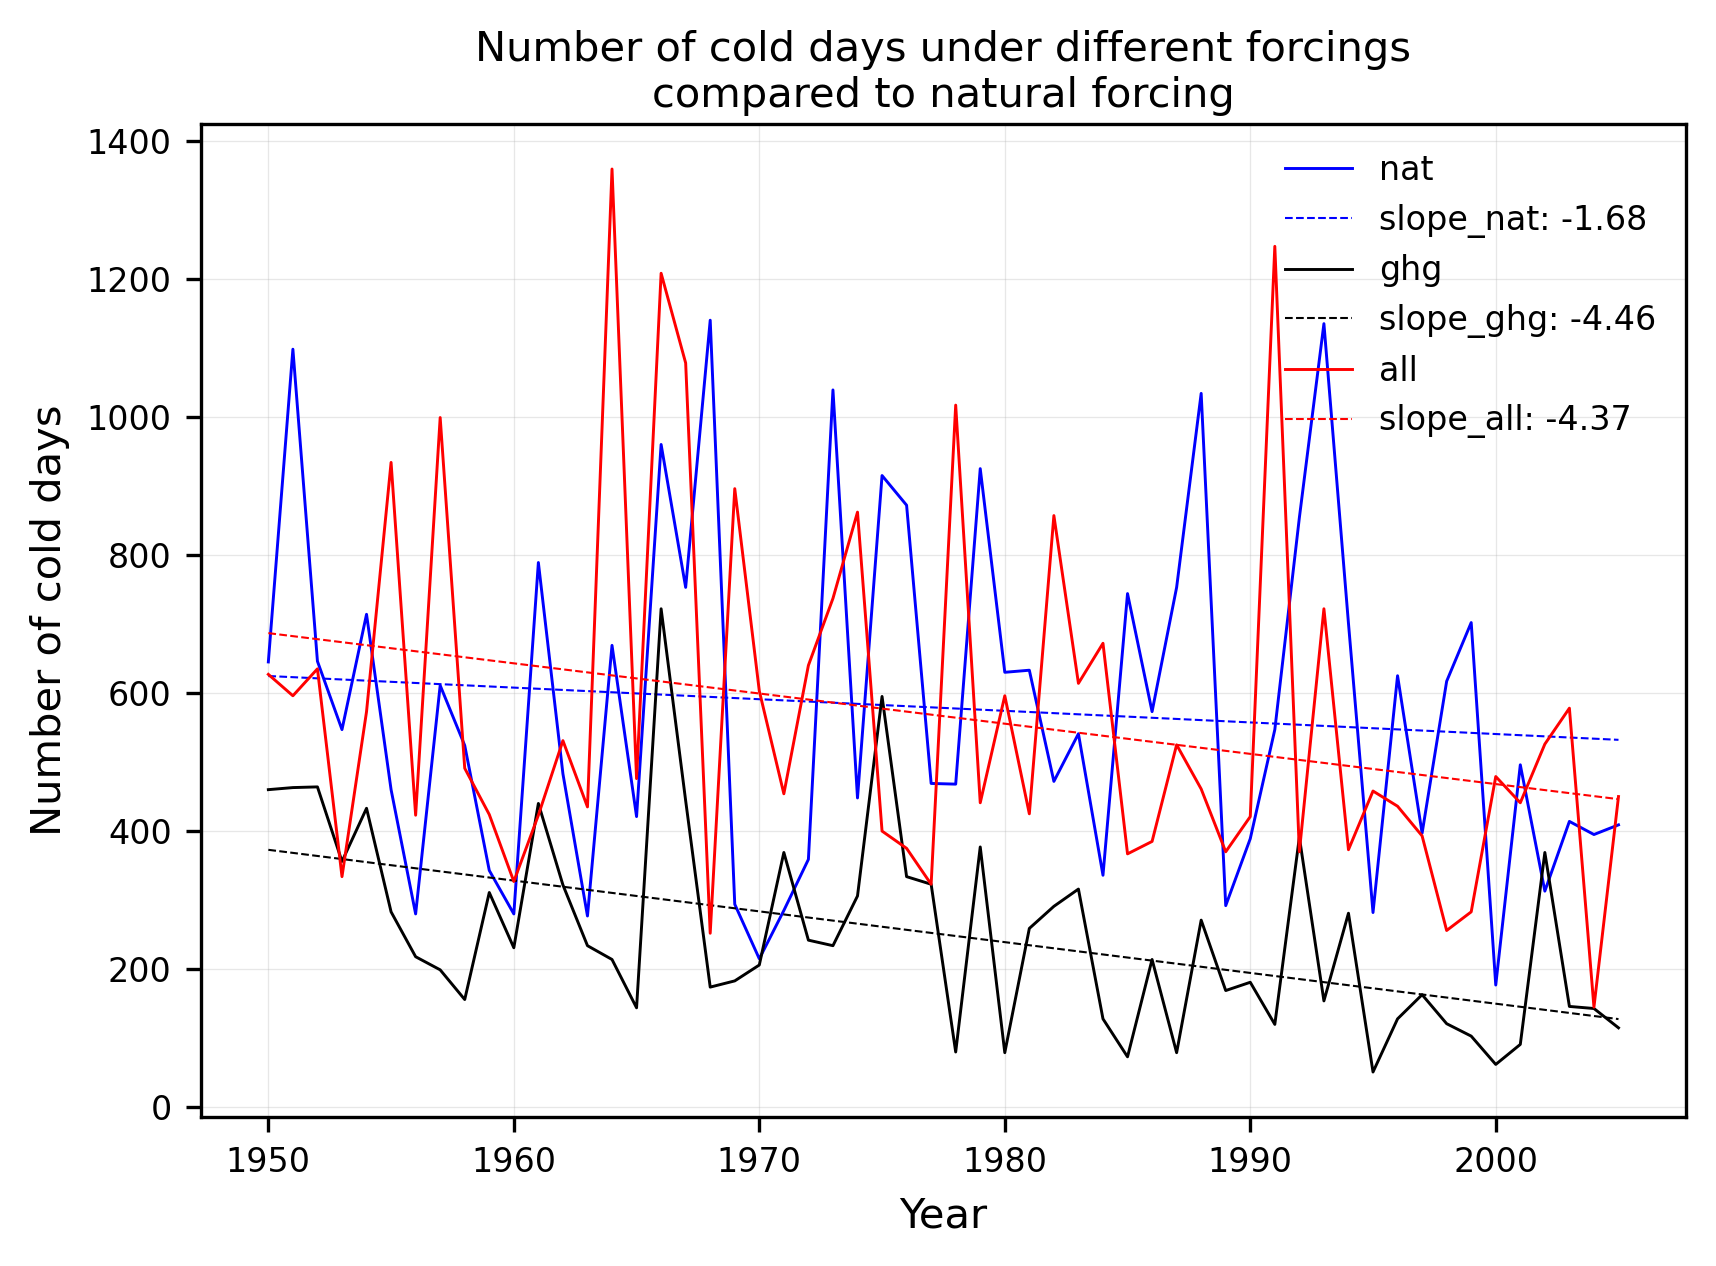

In [43]:
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["cold"]["day_comp"][sce][:, 1],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["cold"]["days_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['cold']['days_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of cold days under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of cold days", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "cold_days_py.png"), bbox_inches="tight")
#plt.close(fig)

In [44]:
for sce in scenarios:
    for ext in temp_ext:
        print(
            "pvalue_%s_%s :" % (sce, ext),
            th[ext]["days_pr_stats"][sce]["pvalue"],
            "rvalue_%s_%s :" % (sce, ext),
            th[ext]["days_pr_stats"][sce]["rvalue"],
        )


# Hot days <e>

# Heat waves using ndimage <b>
th["heat"]["waves"] = {}
th["cold"]["waves"] = {}
str_hw = np.ones((3))

for sce in scenarios:
    for ext in temp_ext:
        tmp_3d_ar = np.ma.masked_equal(
            np.zeros((len(yrs), ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1])), 0
        )
        for idx, yr in enumerate(yrs):
            for idx_lat in range(ocean_mask_conus.mask.shape[0]):
                for idx_lon in range(ocean_mask_conus.mask.shape[1]):
                    tmp_ar = th[ext]["comp"][sce][(idx + 1) * 365 - 365 : (idx + 1) * 365, idx_lat, idx_lon]
                    # labeling all the continuous extreme events
                    larray, narray = ndimage.label(tmp_ar, structure=str_hw)
                    if narray > 0:
                        # identifying the locations of the blobs
                        locations = ndimage.find_objects(larray)
                        hw_count = []
                        for loc in locations:
                            consec_days = np.sum(tmp_ar[loc])
                            if consec_days > 5:
                                hw_count.append(1)
                        hw_count = np.array(hw_count)
                    else:
                        hw_count = np.array([0])
                    tmp_3d_ar[idx, idx_lat, idx_lon] = np.sum(hw_count)
        th[ext]["waves"][sce] = tmp_3d_ar.copy()

th["heat"]["slope_pp"] = {}
th["cold"]["slope_pp"] = {}

for sce in scenarios:
    for ext in temp_ext:
        slope_pp_hw = np.ma.masked_equal(np.zeros((ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1])), 0)
        for idx, yr in enumerate(yrs):
            for idx_lat in range(ocean_mask_conus.mask.shape[0]):
                for idx_lon in range(ocean_mask_conus.mask.shape[1]):
                    tmp_ar = th[ext]["waves"][sce][:, idx_lat, idx_lon]
                    m, c, _, _, _ = stats.linregress(yrs, tmp_ar)
                    slope_pp_hw[idx_lat, idx_lon] = m * 100
        th[ext]["slope_pp"][sce] = np.ma.array(slope_pp_hw, mask=ocean_mask_conus.mask)  # Slope in percentage per pixel

pvalue_all_heat : 2.8268639402337866e-06 rvalue_all_heat : 0.5798249571902782
pvalue_all_cold : 0.043209911541407416 rvalue_all_cold : -0.27118845579011
pvalue_nat_heat : 0.7007453259555758 rvalue_nat_heat : -0.052504959751562996
pvalue_nat_cold : 0.4232529471994364 rvalue_nat_cold : -0.10915169460964858
pvalue_ghg_heat : 4.2920046519132996e-13 rvalue_ghg_heat : 0.7905181184149055
pvalue_ghg_cold : 5.2791550029329134e-05 rvalue_ghg_cold : -0.5130243393434021


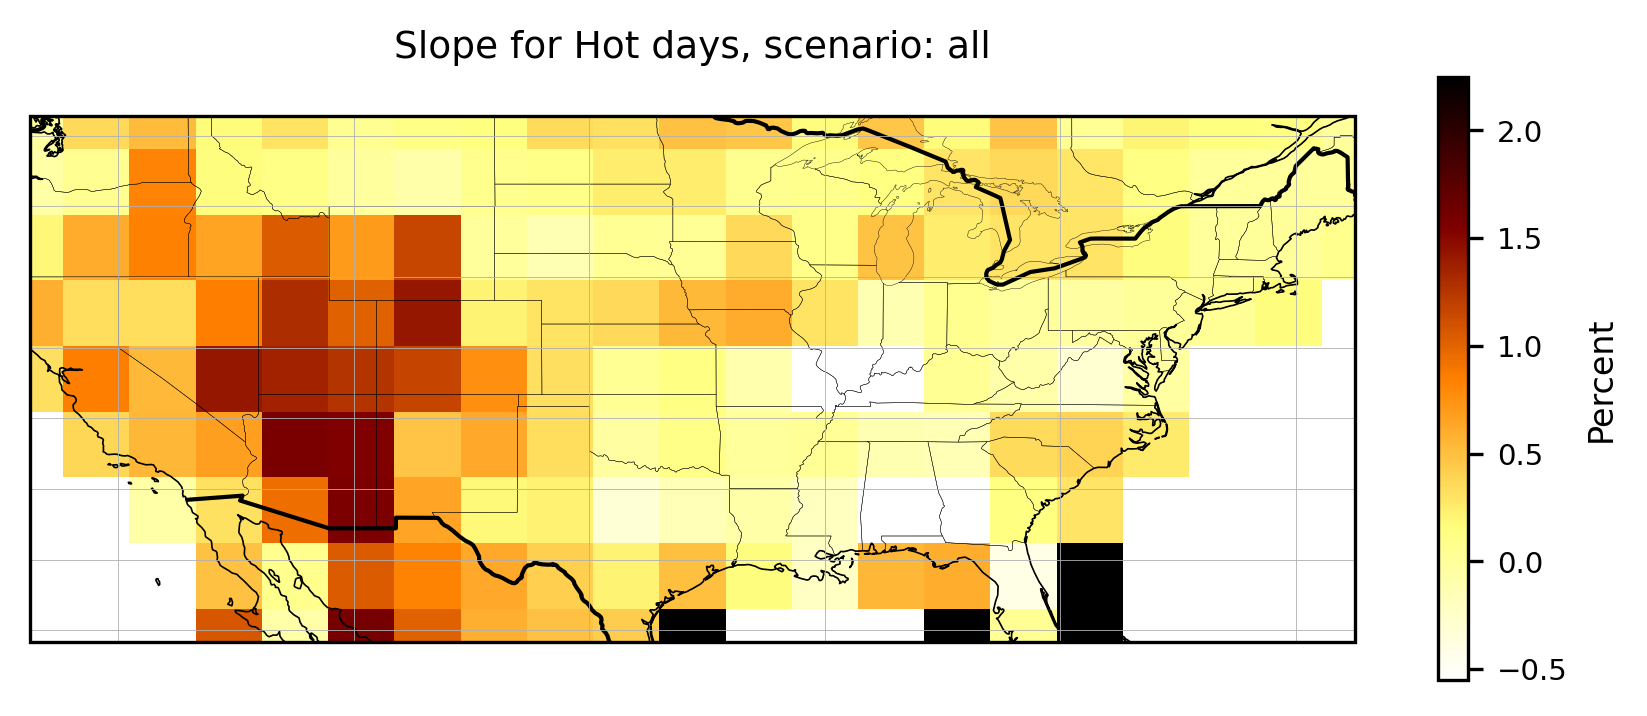

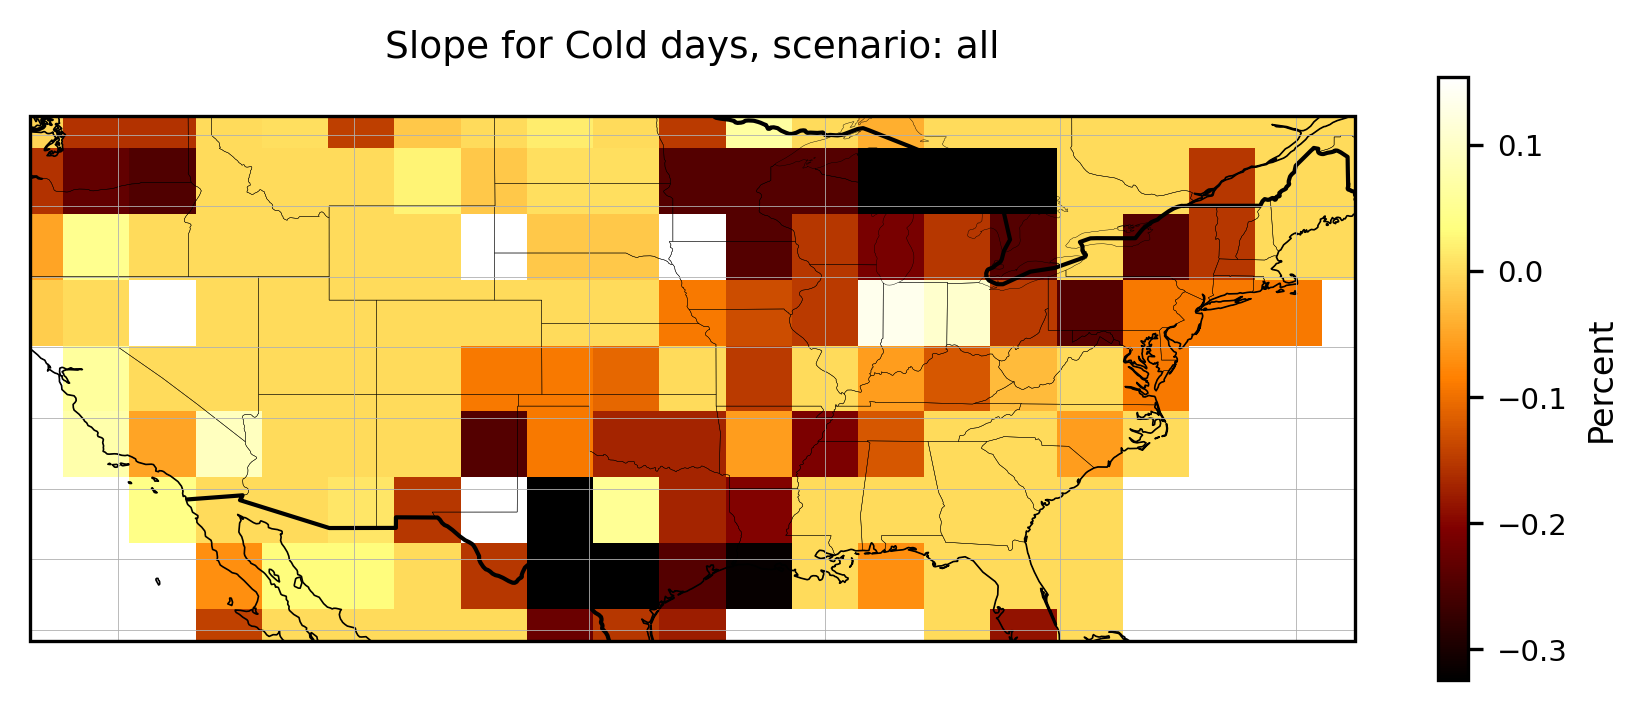

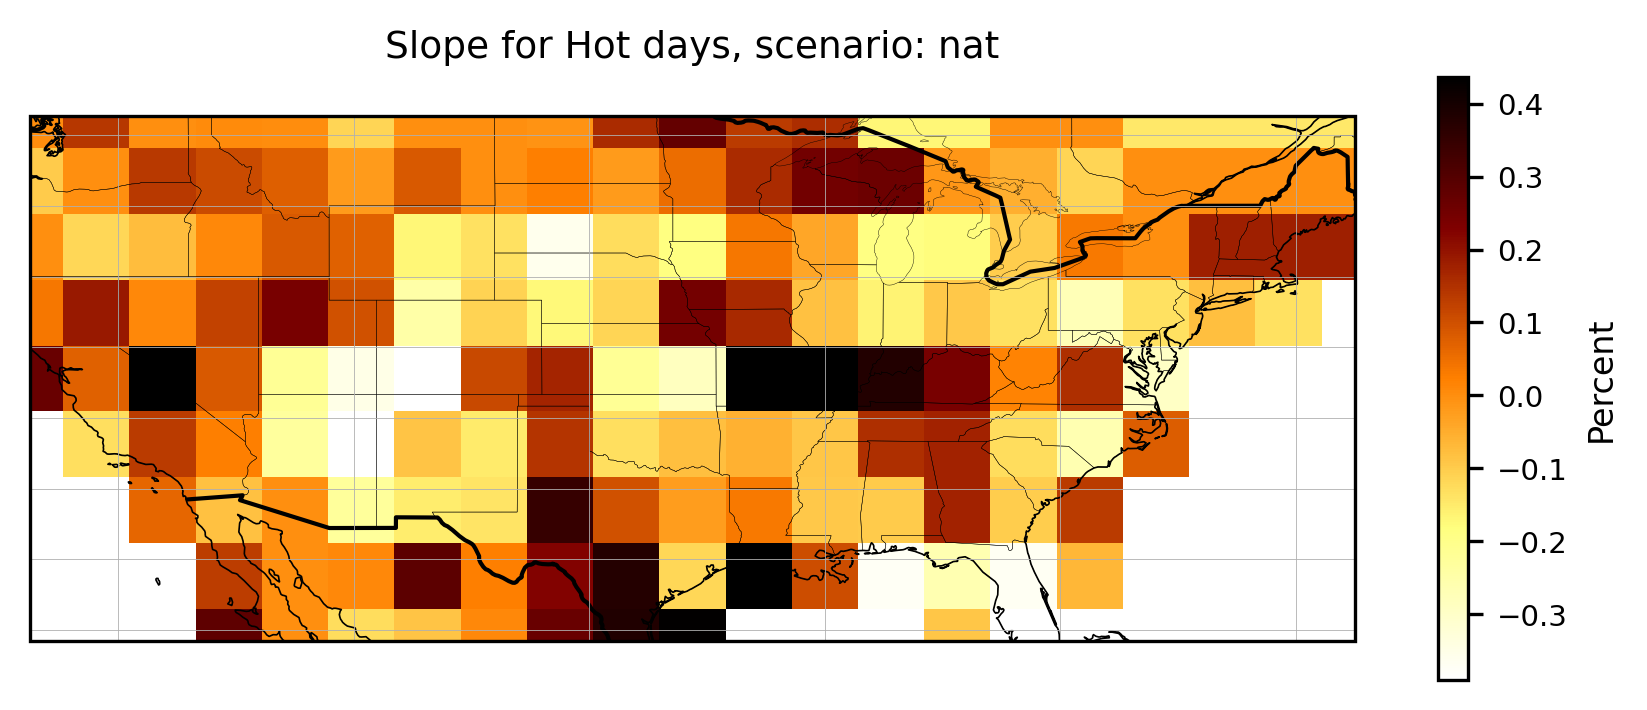

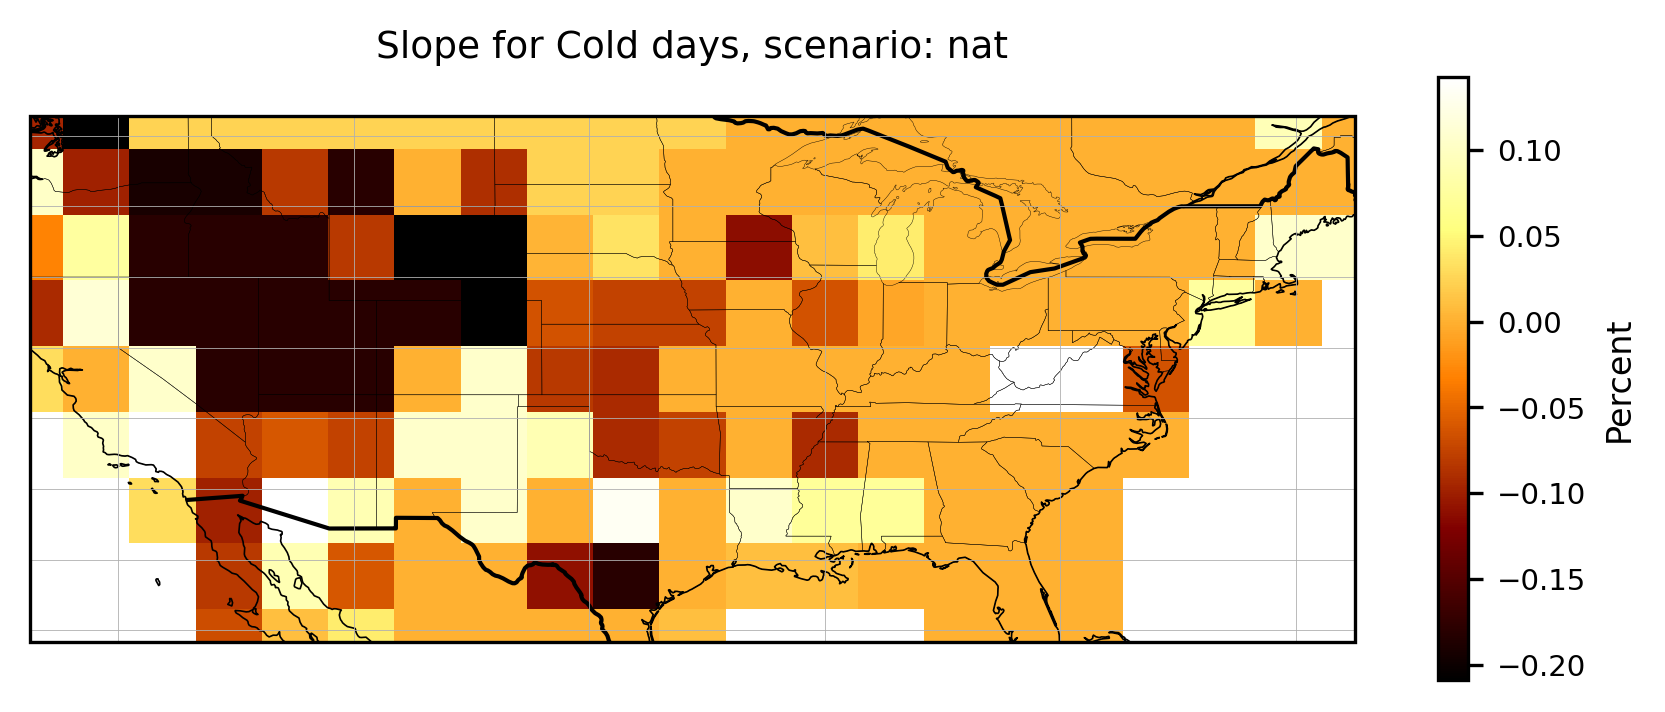

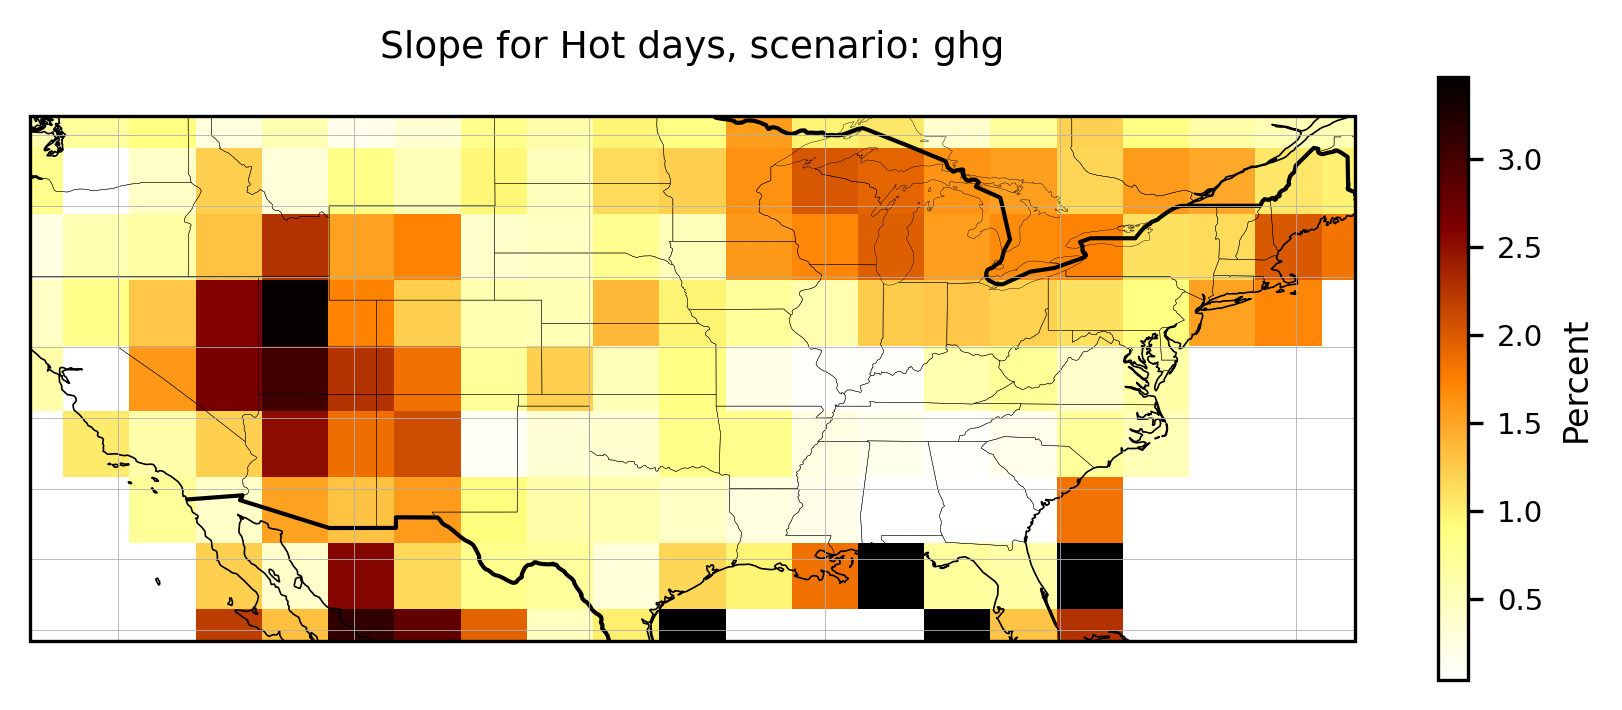

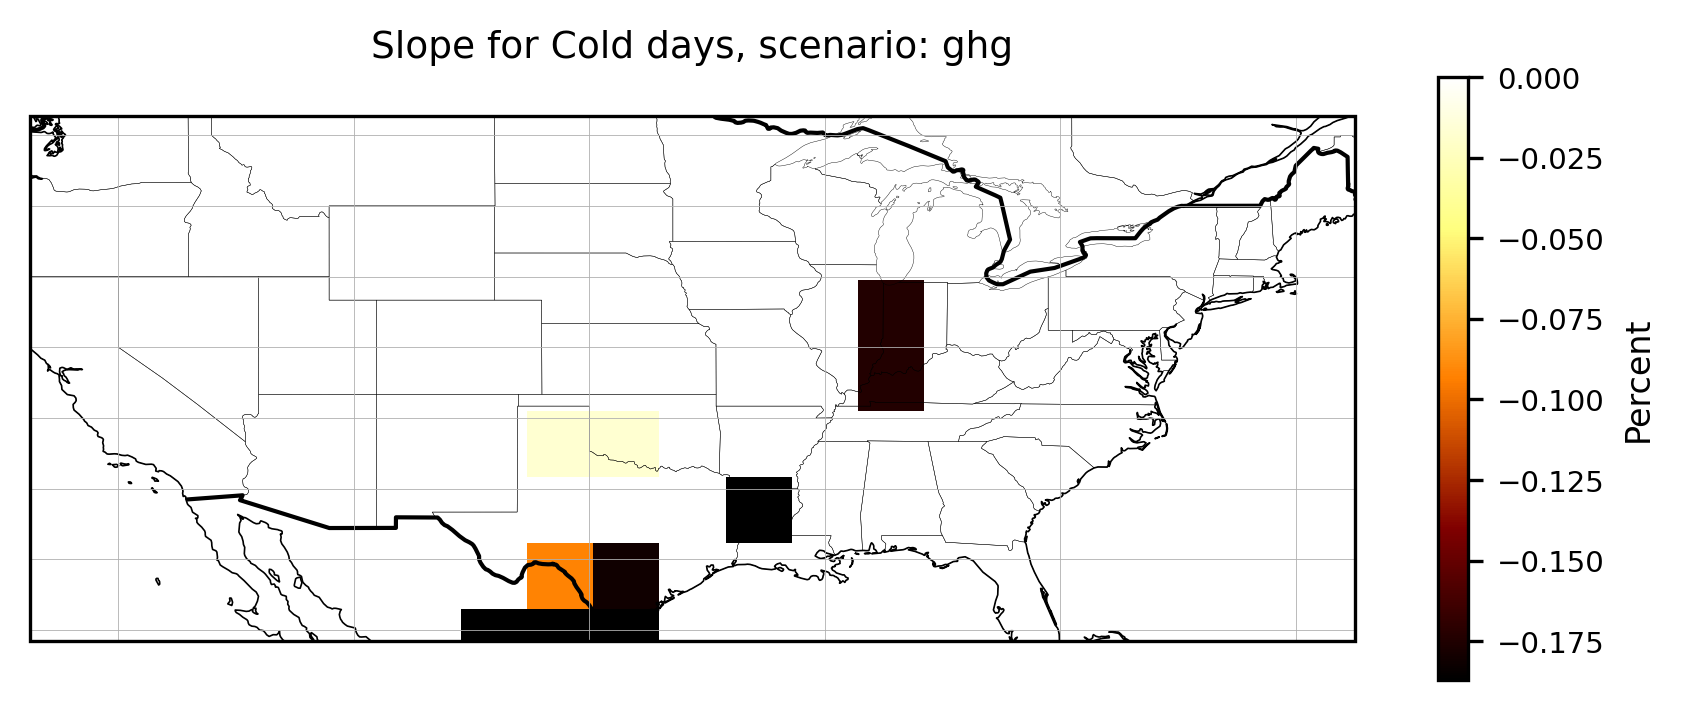

In [54]:
# Labels and colormaps
EXT_LABEL = {"heat": "Hot days", "cold": "Cold days"}
SLOPE_CMAP = {
    "heat": mpl.colormaps["afmhot_r"],
    "cold": mpl.colormaps["afmhot"],
}

# Font sizes consistent with previous maps
TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Plotting slope per pixel
for sce in scenarios:
    for ext in temp_ext:
        data = np.asanyarray(th[ext]["slope_pp"][sce])
        if np.ma.isMaskedArray(data):
            data = data.filled(np.nan)
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        label = EXT_LABEL[ext]

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            th[ext]["slope_pp"][sce],
            transform=ccrs.PlateCarree(),
            cmap=SLOPE_CMAP[ext],
            shading="nearest",
            vmin=vmin,
            vmax=vmax,
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)
        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            shrink=0.5,
            #fraction=0.045,
            #pad=0.02,
        )
        cbar.ax.set_ylabel("Percent", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Slope for {label}, scenario: {sce}\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"slope_{ext}_{sce}.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

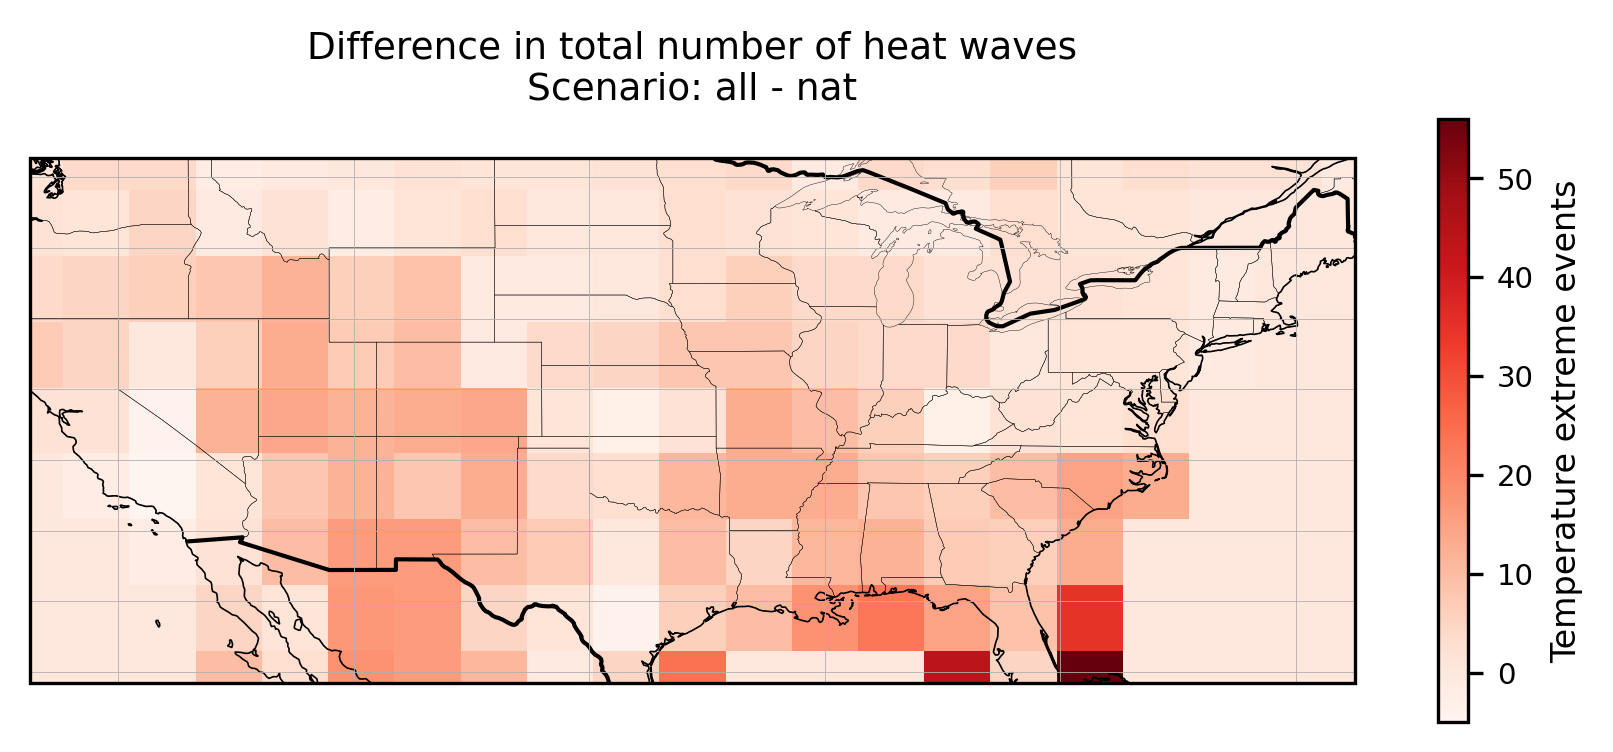

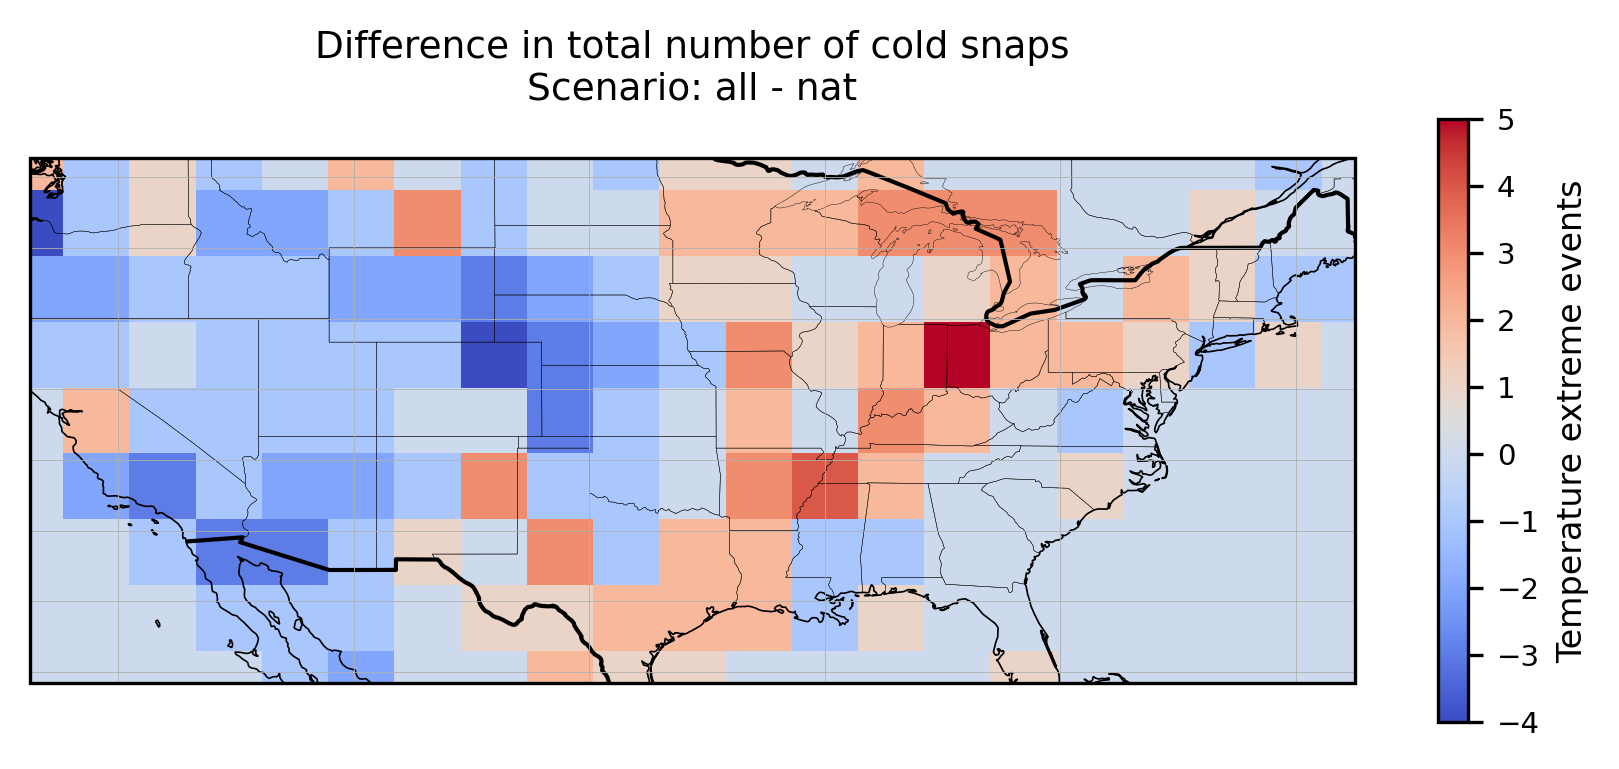

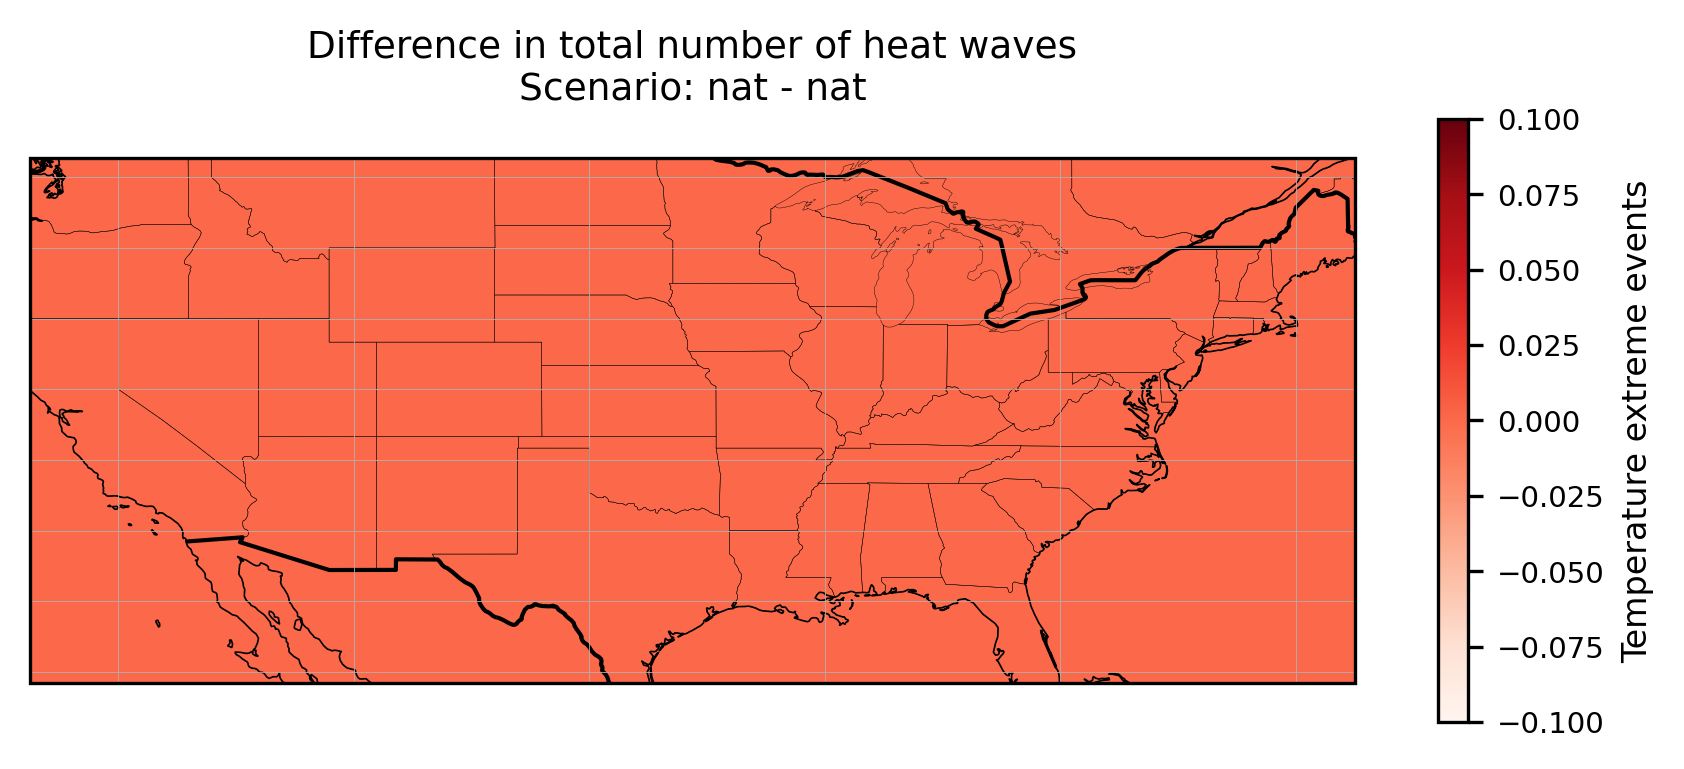

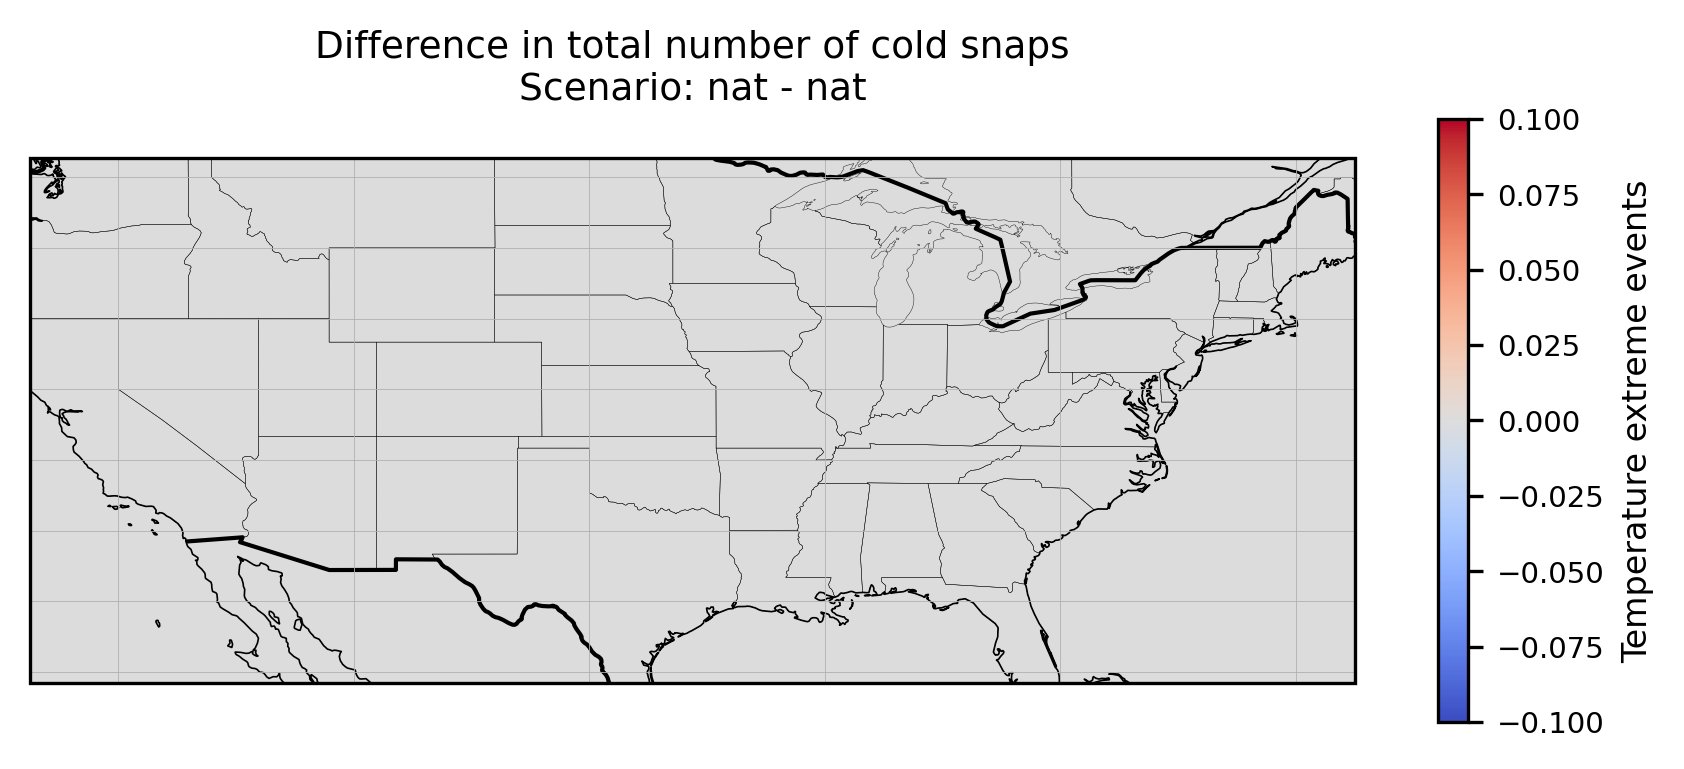

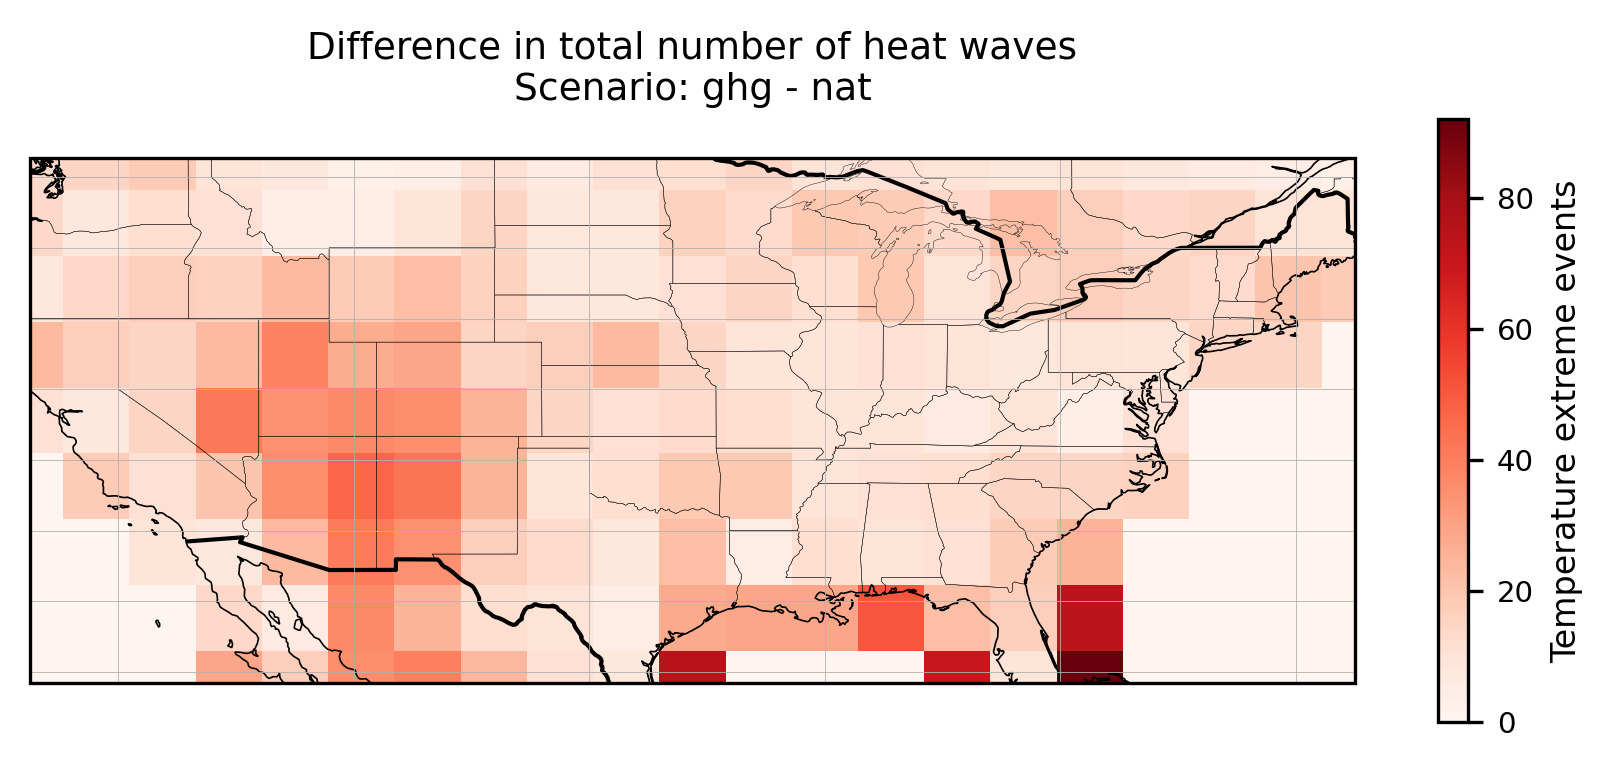

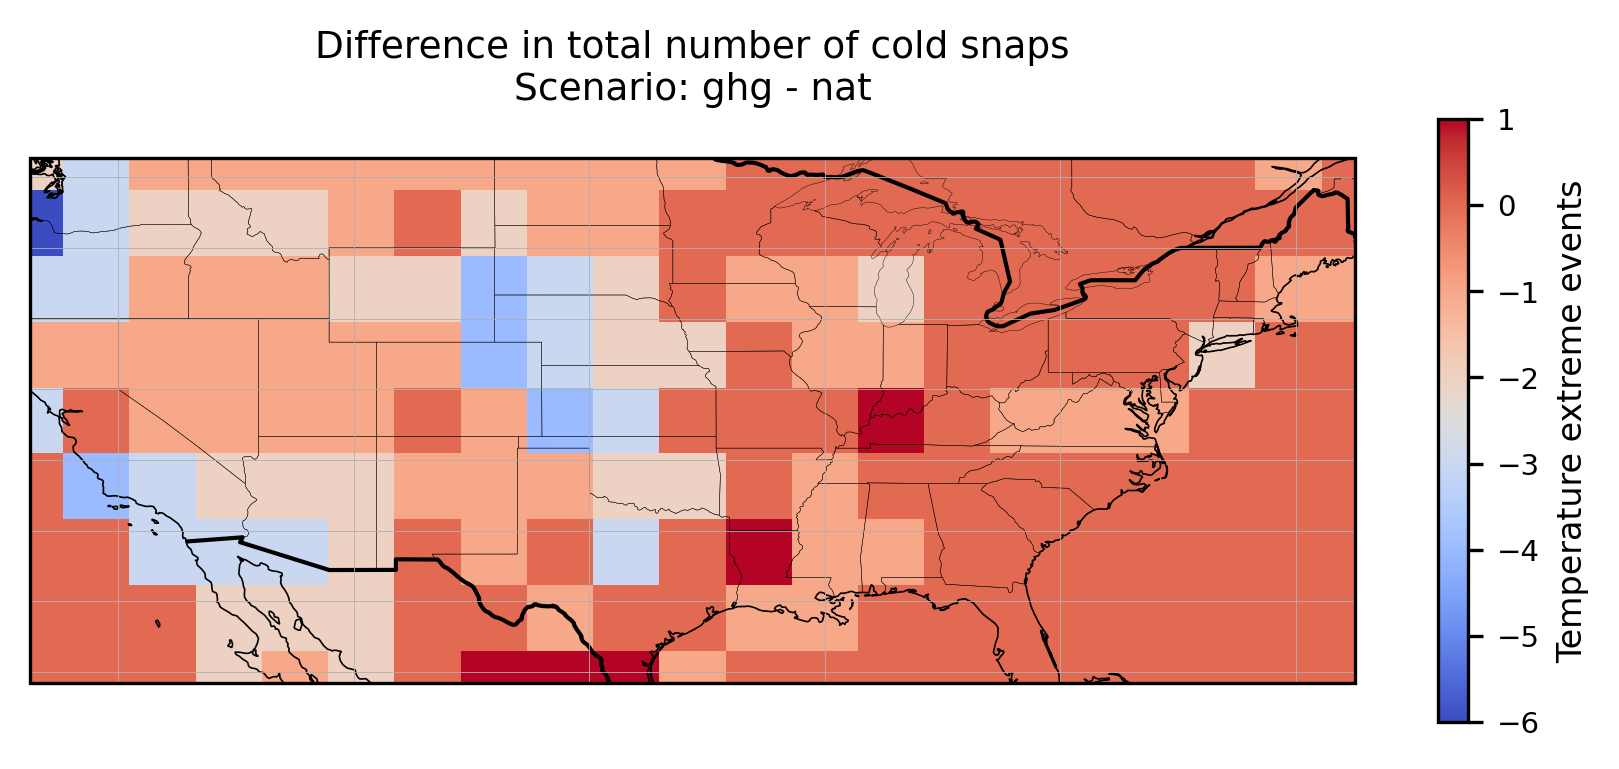

In [56]:


EXT_LABEL = {"heat": "heat waves", "cold": "cold snaps"}
EXT_CMAP_TOTAL_DIFF = {
    "heat": mpl.colormaps["Reds"],
    "cold": mpl.colormaps["coolwarm"],
}

TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Spatial map of total increase in heat/cold waves (scenario vs nat)
for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        total_sce = np.sum(th[ext]["waves"][sce], axis=0)     # (lat, lon)
        total_nat = np.sum(th[ext]["waves"]["nat"], axis=0)   # (lat, lon)
        diff_events = total_sce - total_nat

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff_events,
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP_TOTAL_DIFF[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)
        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            shrink=0.5,
            #fraction=0.045,
            #pad=0.02,
        )
        cbar.ax.set_ylabel("Temperature extreme events", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Difference in total number of {label}\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"diff_{ext}_waves_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        #plt.close(fig)

In [57]:
th["heat"]["waves_pr"] = {}
th["cold"]["waves_pr"] = {}

for sce in scenarios:
    for ext in temp_ext:
        hw_pr = np.zeros((len(yrs)))
        for idx, yr in enumerate(yrs):
            hw_pr[idx] = np.sum(th[ext]["waves"][sce][idx, :, :])
        th[ext]["waves_pr"][sce] = hw_pr.copy()
        print("The total HW/CS %s,%d yrs %s:%d" % (ext, len(yrs), sce, int(th[ext]["waves"][sce].sum())))

th["heat"]["waves_pr_stats"] = {}
th["cold"]["waves_pr_stats"] = {}
for sce in scenarios:
    th["heat"]["waves_pr_stats"][sce] = {}
    th["cold"]["waves_pr_stats"][sce] = {}
# finding the stats of the increase/decrease of heat waves/cold snaps
for sce in scenarios:
    (
        th["heat"]["waves_pr_stats"][sce]["slope"],
        th["heat"]["waves_pr_stats"][sce]["intercept"],
        th["heat"]["waves_pr_stats"][sce]["rvalue"],
        th["heat"]["waves_pr_stats"][sce]["pvalue"],
        th["heat"]["waves_pr_stats"][sce]["stderr"],
    ) = stats.linregress(yrs, th["heat"]["waves_pr"][sce])
    (
        th["cold"]["waves_pr_stats"][sce]["slope"],
        th["cold"]["waves_pr_stats"][sce]["intercept"],
        th["cold"]["waves_pr_stats"][sce]["rvalue"],
        th["cold"]["waves_pr_stats"][sce]["pvalue"],
        th["cold"]["waves_pr_stats"][sce]["stderr"],
    ) = stats.linregress(yrs, th["cold"]["waves_pr"][sce])

for sce in scenarios:
    for ext in temp_ext:
        trend_tmp = []
        for y in yrs:
            trend_tmp.append(th[ext]["waves_pr_stats"][sce]["slope"] * y + th[ext]["waves_pr_stats"][sce]["intercept"])
        th[ext]["waves_pr_stats"][sce]["trend"] = np.array(trend_tmp)


The total HW/CS heat,56 yrs all:1433
The total HW/CS cold,56 yrs all:172
The total HW/CS heat,56 yrs nat:519
The total HW/CS cold,56 yrs nat:166
The total HW/CS heat,56 yrs ghg:3296
The total HW/CS cold,56 yrs ghg:15


In [58]:
for sce in scenarios:
    for ext in temp_ext:
        print(
            "pvalue_%s_%s :" % (sce, ext),
            th[ext]["waves_pr_stats"][sce]["pvalue"],
            "rvalue_%s_%s :" % (sce, ext),
            th[ext]["waves_pr_stats"][sce]["rvalue"],
        )

pvalue_all_heat : 4.495286584135499e-05 rvalue_all_heat : 0.5170851185818836
pvalue_all_cold : 0.1268657818133694 rvalue_all_cold : -0.20644938355242423
pvalue_nat_heat : 0.992372033527423 rvalue_nat_heat : -0.0013070396783911539
pvalue_nat_cold : 0.6458958389723868 rvalue_nat_cold : -0.06275422434454758
pvalue_ghg_heat : 1.4048331158416018e-09 rvalue_ghg_heat : 0.7041655455087436
pvalue_ghg_cold : 0.05413985000807098 rvalue_ghg_cold : -0.25876914789747785


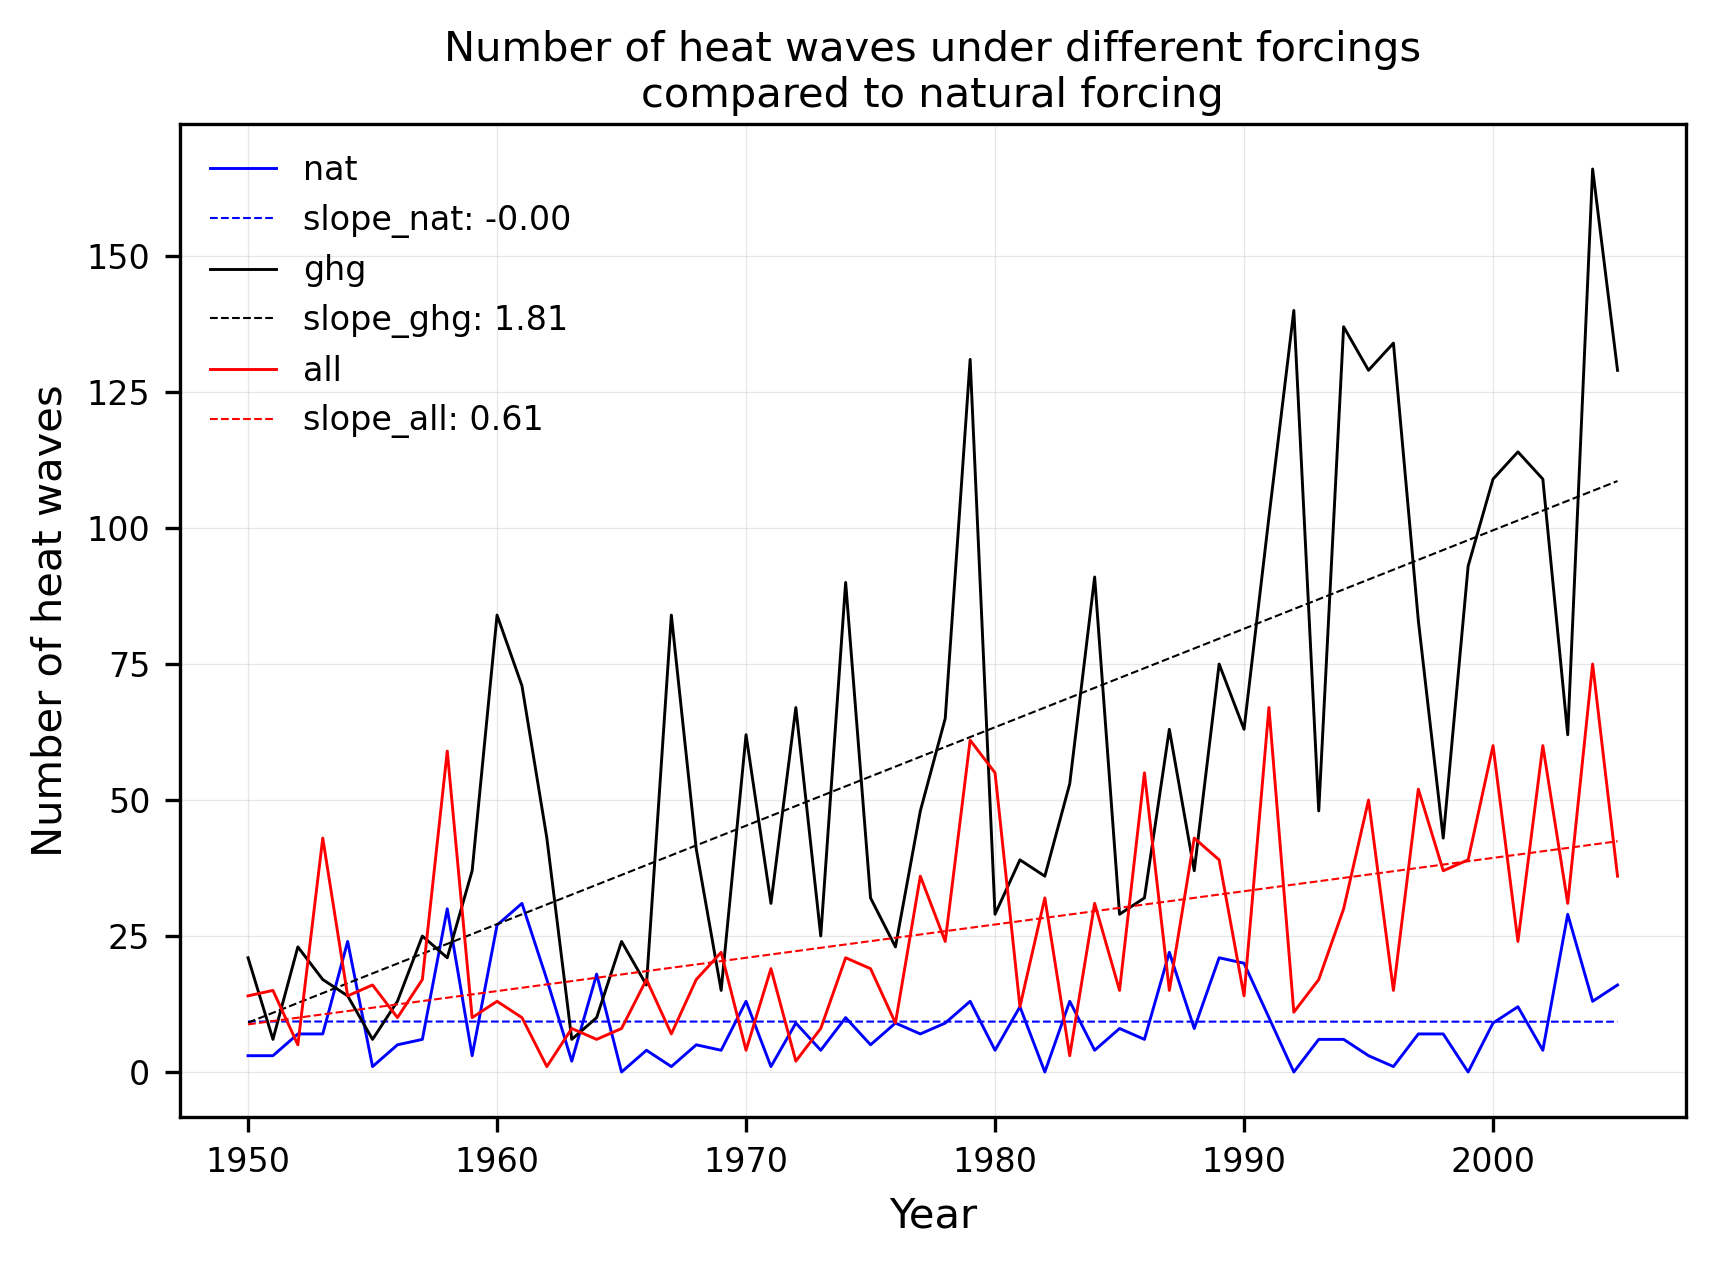

In [61]:
# 1. Compute trend statistics for heat waves
th["heat"]["waves_pr_stats"] = {}

for sce in scenarios:
    th["heat"]["waves_pr_stats"][sce] = {}
    # waves_pr[sce]: 1D array, length = len(yrs), number of heat waves per year
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["heat"]["waves_pr"][sce]
    )
    stats_dict = th["heat"]["waves_pr_stats"][sce]
    stats_dict["slope"] = slope
    stats_dict["intercept"] = intercept
    stats_dict["rvalue"] = rvalue
    stats_dict["pvalue"] = pvalue
    stats_dict["stderr"] = stderr
    stats_dict["trend"] = slope * np.asarray(yrs) + intercept

# 2. Plot style (consistent with previous time-series)
title_fs = 10
label_fs = 10
tick_fs = 8
legend_fs = 8
line_fs = 0.7
trend_fs = 0.5

colors = {"nat": "b", "ghg": "k", "all": "r"}

# 3. Heat waves plot
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["heat"]["waves_pr"][sce],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["heat"]["waves_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['heat']['waves_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of heat waves under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of heat waves", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "heat_waves_py.png"), bbox_inches="tight")
#plt.close(fig)

## attr

In [62]:
def norm(arr):
    if np.max(arr) == np.min(arr):
        return np.array([0] * len(arr))
    return np.array([(x - np.min(arr)) / (np.max(arr) - np.min(arr)) for x in arr])

In [69]:
us_cities = pd.read_csv('cities.csv')
us_cities

,Rank_2025,City,State,Population_Estimate_2000,Population_Estimate_2025,Population_Growth_2000_to_2025_Pct,Latitude,Longitude,Population_2000_Source_URL,Population_2025_Source_URL,Coordinates_Source_URL
0,1,New York,New York,8017608,8584629,7.07,40.712784,-74.005941,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
1,2,Los Angeles,California,3701062,3869089,4.54,34.052234,-118.243685,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
2,3,Chicago,Illinois,2891582,2731585,-5.53,41.878114,-87.629798,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
3,4,Houston,Texas,1974324,2397315,21.42,29.760427,-95.369803,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
4,5,Phoenix,Arizona,1326682,1665481,25.54,33.448377,-112.074037,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
5,6,Philadelphia,Pennsylvania,1514563,1574281,3.94,39.952584,-75.165222,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
6,7,San Antonio,Texas,1153843,1548422,34.20,29.424122,-98.493628,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
7,8,San Diego,California,1227854,1406106,14.52,32.715738,-117.161084,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
8,9,Dallas,Texas,1188168,1329491,11.89,32.776664,-96.796988,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
9,10,Fort Worth,Texas,547484,1028117,87.79,32.755488,-97.330766,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...


In [72]:
slope_hw = []
slope_cs = []

In [73]:
for rank in range(30):
    city_lat = us_cities.loc[rank]['Latitude']
    city_lon = us_cities.loc[rank]['Longitude']
    m_hw = th['heat']['slope_pp']['all'][geo_idx(city_lat,lats_conus),geo_idx(city_lon+360,lons_conus)]
    m_cs = th['cold']['slope_pp']['all'][geo_idx(city_lat,lats_conus),geo_idx(city_lon+360,lons_conus)]
    slope_hw.append(m_hw)
    slope_cs.append(m_cs)
us_cities['Slope_HW'] = slope_hw
us_cities['Slope_CS'] = slope_cs

In [77]:
us_cities.to_csv('cities_HW.csv')

In [49]:
ls /global/u2/b/bharat/repos/hwconus/plots

diff_cold_days_all-nat.png  th_cold_all.png           th_diff_heat_all-nat.png
diff_cold_days_ghg-nat.png  th_cold_ghg.png           th_diff_heat_ghg-nat.png
diff_cold_days_nat-nat.png  th_cold_nat.png           th_diff_heat_nat-nat.png
diff_heat_days_all-nat.png  th_diff_cold_all-nat.png  th_heat_all.png
diff_heat_days_ghg-nat.png  th_diff_cold_ghg-nat.png  th_heat_ghg.png
diff_heat_days_nat-nat.png  th_diff_cold_nat-nat.png  th_heat_nat.png
